# Problems Notebook
---

This notebook contains my work of the assessment in Applied Statistics module in the Higher Diploma in Data Analytics course. 

The notebook covers four main problems: 

* **Problem 1: Extending the Lady Tasting Tea**
* **Problem 2: Normal Distribution**
* **Problem 3: t-Test**
* **Problem 4 : ANOVA**

To address the problems above, I will use Python for simulation and visualization, supported by the material covered in lectures and relevant online references.

To begin, I will import the necessary libraries. These will be used throughout the analysis for the parts of the problems.

In [637]:
# Import necessary libraries

# for mathematical functions
# see https://docs.python.org/3/library/math.html
import math

# for combinatorial functions
# see https://docs.python.org/3/library/itertools.html
import itertools as it

# for random number generation
# see https://www.w3schools.com/python/module_random.asp
import random

# for numerical operations
# see https://www.w3schools.com/python/numpy/numpy_intro.asp
import numpy as np

# for data visualization and plotting
# see https://www.w3schools.com/python/matplotlib_pyplot.asp
import matplotlib.pyplot as plt

# for statistical functions
# see https://www.geeksforgeeks.org/python/scipy-stats/
import scipy.stats as stats

# statistical models
# see https://www.geeksforgeeks.org/data-science/statsmodel-library-tutorial/
import statsmodels as sm


# for statistical plots
# see https://seaborn.pydata.org/
import seaborn as sns

# for data frames
# see https://pandas.pydata.org/docs/
import pandas as pd



Let's go through each of the problem.

## Problem 1: Extending the Lady Tasting Tea:
---

Let's extend the Lady Tasting Tea experiment as follows. The original experiment has 8 cups: 4 tea-first and 4 milk-first. Suppose we prepare 12 cups: 8 tea-first and 4 milk-first. A participant claims they can tell which was poured first.

Simulate this experiment using numpy by randomly shuffling the cups many times and calculating the probability of the participant correctly identifying all cups by chance. Compare your result with the original 8-cup experiment.

In your notebook, explain your simulation process clearly, report and interpret the estimated probability, and discuss whether, based on this probability, you would consider extending or relaxing the p-value threshold compared to the original design.

### Solution to the Problem 1
---

In the [**Original Lady Tasting Tea**](https://en.wikipedia.org/wiki/Lady_tasting_tea) experiment devised by [Ronald Fisher](https://en.wikipedia.org/wiki/Ronald_Fisher) we had **8 cups: 4 tea first and 4 milk first.** The Lady's task was to select the correct 4 milk first cups. The experiment asked whether the Lady could tell if the milk was added before the tea.

In this Extended experiment, we have:

* **Total cups $(n)$** : 12
* **Composition** : 8 Tea-first and 4 milk-first
* **Participant task $(k)$ :** Identify the 8 tea-first cups. 


The primary selection is that participant selects a set of 8 cups and they automatically leave a set of 4 unselected cups which will be labelled as tea-first. 

We only need to track the accuracy of 8-cup selection, because a perfect match in that set logically requires a perfect match in the 4-cup set (which will also be checked). 

The core probablility is calculated using [combination](https://en.wikipedia.org/wiki/Combination) which is the number of ways to choose a subset from a larger set where the order does not matter. 

It is written and calculated as [factorial](https://en.wikipedia.org/wiki/Factorial) notation: 

$\binom{n}{k} = \frac{n!}{k!(n-k)!}$




**Total possible Outcome**

The mathematical explanation below is showing the total number of unique ways the participant can choose any 4 cups from the 12 total cups of tea, and the same 8 cups from the 12 total cups of tea. 


$
\binom{12}{4}
= \frac{12!}{4!(12-4)!}
= \frac{12!}{4!8!}
= \frac{479,001,600}{24 \times 40,320}
= \frac{479,001,600}{967,680}
= 495
$

$
\binom{12}{8}
= \frac{12!}{8!(12-8)!}
= \frac{12!}{8!4!}
= \frac{479{,}001{,}600}{40{,}320 \times 24}
= \frac{479{,}001{,}600}{967{,}680}
= 495
$

It does not matter whether we ask how many ways to pick 4 milk-first or how many ways to pick 8 tea-first, the result is still the same: 495.

This is because choosing 8 cups **is the same** as choosing 4 cups that **are not** selected. 

**The Single Correct Outcome** 

To get a perfect score, the participant must select 8 cups that exactly matches the 8 cups that actually are tea-first. There is only one way to achieve this. 

$\
P(\text{Perfect Score})
= \frac{\text{Number of ways to get all 8 milk-first correct}}
       {\text{Total number of ways to select 8 cups}}
= \frac{1}{495}
\approx 0.00202
$


In this scenario, a perfect score means the chance of that result occurring randomly is **0.202%** which is 1 in 495 chance. 

For this experiment, we set up a [statistical hypotesis](https://www.datacamp.com/tutorial/hypothesis-testing) test. We assume that the [**Null Hypothesis $(H_0)$**](https://en.wikipedia.org/wiki/Null_hypothesis) is true: the participant is selecting cups **at random** and has **no special ability**. 

The [**Altern Hypothesis $(H_A)$**](https://en.wikipedia.org/wiki/Alternative_hypothesis) is that the participant **does have** the ability.

The objective is to calculate and simulate the probability [($p$-value)](https://en.wikipedia.org/wiki/P-value) of getting a perfect score purely by chance if $(H_0)$ is true. I will use this probability to decide whether there is sufficient evidence to reject the *Null Hypothesis* in favor of the *Alternative Hypothesis*. 

Let's go through this using Python. 

#### Mathematical Concepts
---


I use [`math.comb(n, k)`](https://docs.python.org/3/library/math.html#math.comb) to find the total number of possible ways the participant could select the cups, which determines the theoretical probability (or $p$-value) of a perfect guess by chance ($1 / \text{Total Ways}$). 

##### Cups of Tea in Original Experiment
---

Let's see the original experiment first. 

In [638]:

# Number of cups of tea. All cups are identical. 
num_cups= 8

# Number of cups with tea first
num_tea_first = 4

# Number of cups with milk first
num_milk_first= 4

In [639]:
# Number of ways to select 8 cups from 12
n = num_cups
k = num_tea_first

tea_ways_org = math.comb(n, k)

print(f'Number of ways to select cups is {tea_ways_org}')

Number of ways to select cups is 70


The original Lady Tasting Tea experiment has $n$ = 8 total cups, and $k$ = 4 were to be selected (4 milk-first and 4 tea-first). 

The total number of unique ways to select 4 cups from 8 is:


$
\binom{8}{4}
= \frac{8!}{4!(8-4)!}
= \frac{8!}{4!4!}
= 70
$


The probability of selecting the single correct combination by chance is $\frac{1}{70}$ ≈ **0.01429** which is about **1.429%** chance. 

##### Cups of Tea in Extended Experiment
---

The goal of this experiment is to test the participant's ability to identify 8 tea-first cups from a total of 12 cups (where the remaining 4 are milk first). We calculate the total number of unique ways the participant could make their selection (the denominator for our probability).

**Initial Calculation: Combinatorial Symmetry**

The experiment requires the participant to identify the $k=8$ tea-first cups out of $N=12$ total cups. The number of ways to choose 8 cups is the same as the number of ways to choose the remaining 4 cups.

In [640]:
# Number of cups of tea. All cups are identical. 
num_cups_ex = 12

# Number of cups with tea first
num_tea_first_ex = 8

# Number of cups with milk first
num_milk_first_ex = 4

In [641]:
# Number of ways to select 8 cups from 12

tea_ways_ex = math.comb(num_cups_ex, num_tea_first_ex)

print(f'Number of ways to select cups is {tea_ways_ex}')

Number of ways to select cups is 495


In [642]:
# number of ways to select 4 cups from 12
milk_ways_ex = math.comb(num_cups_ex, num_milk_first_ex)

print(f'Number of ways to select cups is {milk_ways_ex}')

Number of ways to select cups is 495


In [643]:
# probability of a perfect selection 8 cups from 12
perfect_selection_prob_tea = 1 / tea_ways_ex

print(f'Probability of perfect selection of tea-first is {perfect_selection_prob_tea * 100}%')

Probability of perfect selection of tea-first is 0.20202020202020202%


In [644]:
# probability of selecting 4 cups with tea first from 8 cups

perfect_selection_prob_milk = 1 / milk_ways_ex

print(f'Probability of perfect selection of milk-first is {perfect_selection_prob_milk * 100}%')

Probability of perfect selection of milk-first is 0.20202020202020202%


Both results shows 495 which is **1 in 495 chances**. 
This means the probability of a perfect score (if guessing randomly) is $\mathbf{1 \text{ in } 495}$ (or $0.202\%$).

Although these results might ***not look exaclty*** the same - **if we choose 8 cups to have tea first, it leaves us with remaining 4 cups with milk. If we choose 4 cups with milk, we will have 8 cups remaining** - we can confirm they are mathematically equivalent.  



Let's go through further calculations carefully. 

##### Exploring the Combinatorial Formula
---


**[Permutation (Order Matters) and Combination (Order does NOT Matter)](https://www.geeksforgeeks.org/maths/permutations-and-combinations/)**

We first calculate the number of ordered ways to select 8 cups from 12. This is a [permutation](https://www.geeksforgeeks.org/maths/permutation/), $P(12, 8)$.

We can demonstrate the result using the following calculations to select the 8 tea-first cups and confirm the mathematical equivalence as to selecting 4 milk-first, $\binom{12}{4} = \binom{12}{8}$.

Let's label the 12 cups of tea from the extened experiment `1`, `2`, `3`, `4`, `5`, `6`, `7`, `8`, `9`, `10`, `11`, `12`. 

We select 8 cups to have tea poured in first.

For example, we might select `1`, `2`, `4`, `6`, `9`, `10`, `11` and `12`.

Visualize having eight saucers where we place eight of the cups.

How many ways are there to select 8 cups from 12?

Cups: `1 2 3 4 5 6 7 8 9 10 11 12`

Saucers: `_ _ _ _ _ _ _ _`

In [645]:
# Total number of ways of selecting 8 cups from 12, keeping them in order.
ways_ordered_tea = 12 * 11 * 10 * 9 * 8 * 7 * 6 * 5

# Show.
ways_ordered_tea

19958400

The multiplication $12 \times 11 \times 10 \times 9 \times 8 \times 7 \times 6 \times 5$ starts with the total number of options (12) and multiplies it by the decreasing number of remaining options for each of the 8 choices:

* 12 options for the first cup selected
* 11 options for the second cup selected
* ...
* 5 options for the eighth cup selected.

This results in a large number: $12 \times 11 \times 10 \times 9 \times 8 \times 7 \times 6 \times 5 = \mathbf{19,958,400}$ if the order of selection would matter.

**Combination (Order Does NOT Matter)**

In the Lady Tasting Tea analysis the order **doesn't matter**. If cups `1`, `2`, `4`, `6`, `9`, `10`, `11` and `12`. are selected in order it is the same result as if `12`, `11`, `9`, `10`, `2`, `6`, `4` and `1`. were selected, or any other permutation.

`1 2 4 6 9 10 11 12`

`12 11 9 10 2 6 4`

`_ _ _ _ _ _ _ _`

This calculation finds the number of ways to pick 8 cups 

In [646]:
# No of ways of shuffling 8 cups.
no_shuffles_tea = 8 * 7 * 6 * 5 * 4 * 3 * 2 * 1

# Show.
no_shuffles_tea

40320

The total number of ways the 8 selected cups could be shuffled is $40320$.

To find the correct number of unordered combinations, we need to divide the total number of ways to pick 8 cups by the number of ways to shuffle them.

In [647]:
# No of combinations ups with tea.
no_comb_tea = ways_ordered_tea // no_shuffles_tea

# Show.
no_comb_tea

495

$\binom{12}{8} = \frac{\text{Ways to select } 8 \text{ ordered cups}}{\text{Ways to shuffle the } 8 \text{ selected cups}} = \frac{12 \times 11 \times \dots \times 5}{8!} = \frac{19,958,400}{40,320} = \mathbf{495}$

**Let's check if we get the same result selecting 4 cups to have milk first.**

Again, we have our labeled 12 cups of tea `1`, `2`, `3`, `4`, `5`, `6`, `7`, `8`, `9`, `10`, `11`, `12`. 

But now we select 4 cups to have milk in first. We start again, so we still have 12 cups.

Let's select `3`, `5`, `7`, and `8`.

We place them on the other four saucers where we place four cups on, where we guess the milk is first. 

How many ways are there to select 4 cups from 12?

Cups: `1 2 3 4`

Saucers: `_ _ _ _`

In [648]:
# Total number of ways of selecting 4 cups from 12, keeping them in order.
ways_ordered_milk = 12 * 11 * 10 * 9

# Show.
ways_ordered_milk

11880

The total number of ways to select 4 cups is $11880$

And again, the order doesn't matter. 

In [649]:
# No of ways of shuffling four cups.
no_shuffles_milk = 4 * 3 * 2 * 1

# Show.
no_shuffles_milk

24

The total number of ways to pick 8 selected cups that could be internally shuffled is $24$.

In [650]:
# No of combinations milk.
no_combs_ex = ways_ordered_milk // no_shuffles_milk

# Show.
no_combs_ex

495

$$\binom{12}{4} = \frac{\text{Ways to select } 4 \text{ ordered cups}}{\text{Ways to shuffle the } 4 \text{ selected cups}} = \frac{11,880}{24} = \mathbf{495}$$

There are 495 ways to select 8 cups with tea first, which is similar as choosing 4 cups with milk first. It is just viewed from the opposite perspective.

##### Exploring `math.factorial`
---

Python provides the function [`math.factorial`](https://docs.python.org/3.12/library/math.html#math.factorial) for computing factorials.  

Factorials are the building block of many counting formulas, including the
number of ways to arrange $(n)$ distinct items (permutations).


The factorial of a non-negative integer **$n$**, denoted by **$n!$**, is the product of all positive integers less than or equal to $n$. It is used to calculate the total number of ways to arrange $n$ distinct items in order, also known as the number of **permutations** of $n$ elements

Mathematically denoted as `n!`.

Multiply all positive integers from `n` down to 1.


`n! = n x (n - 1) x (n - 2) x ... x 1`

e.g. `5! = 5 x 4 x 3 x 2 x 1 = 120`

In [651]:
# Number of cups of tea in total.
n = 12

In [652]:
# Number of cups of tea with milk in first.
k = 8

In [653]:
# Twelve factorial.
math.factorial(n)

479001600

In [654]:
# Four factorial.
math.factorial(k)

40320

In [655]:
# Four factorial.
math.factorial(n - k)

24

In [656]:
# No of ways of selecting k objects from n without replacement and without order.
math.factorial(n) // (math.factorial(k) * math.factorial(n - k))

495

This calculation definitively confirms that there are $\mathbf{495}$ $\mathbf{unique}$ $\mathbf{ways}$ for the participant to select 8 cups from the total of 12.

#### Ordering of Results
---

To list all possible selections of cups, we use Python’s
[`itertools.combinations`](https://docs.python.org/3/library/itertools.html#itertools.combinations).

- The function `combinations(iterable, r)` returns all different ways of picking
  `r` items from `iterable` **without regard to order**.
- In this experiment, `iterable` is the set of cup labels and `r` is the number
  of cups the participant claims were poured milk-first.

Each element returned by `combinations` represents **one possible guess pattern**
the participant could make.

Generate the possibilities 

We first label each cup with a simple integer ID (0, 1, 2, …). Then we use
`itertools.combinations` to generate **every possible set of cups** that could
be identified as “milk first”. This gives us the full space of outcomes under
random guessing.

In [657]:
# the cup labels
# integers from 0 up to (but not including) num_cups_ex
# if num_cups_ex = 12, we get [0, 1, 2, ..., 11]
labels = list(range(num_cups_ex))

# show
labels



[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [658]:
# Show the different ways of selecting no_cups_milk_first out of no_cups cups of tea.
combs = list(itertools.combinations(labels, num_tea_first_ex))

# Show.
# all combinations (the entire sample space under random guessing).
combs

[(0, 1, 2, 3, 4, 5, 6, 7),
 (0, 1, 2, 3, 4, 5, 6, 8),
 (0, 1, 2, 3, 4, 5, 6, 9),
 (0, 1, 2, 3, 4, 5, 6, 10),
 (0, 1, 2, 3, 4, 5, 6, 11),
 (0, 1, 2, 3, 4, 5, 7, 8),
 (0, 1, 2, 3, 4, 5, 7, 9),
 (0, 1, 2, 3, 4, 5, 7, 10),
 (0, 1, 2, 3, 4, 5, 7, 11),
 (0, 1, 2, 3, 4, 5, 8, 9),
 (0, 1, 2, 3, 4, 5, 8, 10),
 (0, 1, 2, 3, 4, 5, 8, 11),
 (0, 1, 2, 3, 4, 5, 9, 10),
 (0, 1, 2, 3, 4, 5, 9, 11),
 (0, 1, 2, 3, 4, 5, 10, 11),
 (0, 1, 2, 3, 4, 6, 7, 8),
 (0, 1, 2, 3, 4, 6, 7, 9),
 (0, 1, 2, 3, 4, 6, 7, 10),
 (0, 1, 2, 3, 4, 6, 7, 11),
 (0, 1, 2, 3, 4, 6, 8, 9),
 (0, 1, 2, 3, 4, 6, 8, 10),
 (0, 1, 2, 3, 4, 6, 8, 11),
 (0, 1, 2, 3, 4, 6, 9, 10),
 (0, 1, 2, 3, 4, 6, 9, 11),
 (0, 1, 2, 3, 4, 6, 10, 11),
 (0, 1, 2, 3, 4, 7, 8, 9),
 (0, 1, 2, 3, 4, 7, 8, 10),
 (0, 1, 2, 3, 4, 7, 8, 11),
 (0, 1, 2, 3, 4, 7, 9, 10),
 (0, 1, 2, 3, 4, 7, 9, 11),
 (0, 1, 2, 3, 4, 7, 10, 11),
 (0, 1, 2, 3, 4, 8, 9, 10),
 (0, 1, 2, 3, 4, 8, 9, 11),
 (0, 1, 2, 3, 4, 8, 10, 11),
 (0, 1, 2, 3, 4, 9, 10, 11),
 (0, 1, 2, 3, 5, 6, 7, 8)

This code generates every possible way a participant could randomly guess the 8 tea-first cups out of the 12. Since order does not matter, we use `itertools.combinations`. The output list `combs` contains all
$\binom{12}{8} = 495$ unique guesses, representing the entire sample space under random guessing.

Now, we check the probability of selecting one particular combination by pure random guessing.

In [659]:
# Number of combinations.
len(combs)

495

In [660]:
# Probability of selecting one particular combination.
# Since all combinations are equally likely, the probability is 1 divided by the total number of combinations

1/len(combs)

0.00202020202020202

In [661]:
# Select eight cups at random to put tea in first.
# https://docs.python.org/3/library/random.html#random.sample
labels_tea = random.sample(labels, 8)

# Sort the chosen labels in place so they are easier to read.
labels_tea.sort()

# Show.
labels_tea

[0, 1, 2, 3, 5, 7, 10, 11]

In [662]:
# Turn labels_tea into a set.
# Uses: https://docs.python.org/3/tutorial/datastructures.html#sets
set(labels_tea)

{0, 1, 2, 3, 5, 7, 10, 11}

In [663]:
# Calculate the overlap between each element of combs and labels_tea.

no_overlaps = []


#loop through each combination in combs.
for comb in combs:
  # Turn comb into a set.
  s1 = set(comb)
  # Turn labels_tea into a set.
  s2 = set(labels_tea)
  # Figure out where they overlap.
  overlap = s1.intersection(s2)
  # Show the combination and the overlap.
  print(comb, len(overlap), overlap)
  # Append overlap to no_overlaps.
  no_overlaps.append(len(overlap))

(0, 1, 2, 3, 4, 5, 6, 7) 6 {0, 1, 2, 3, 5, 7}
(0, 1, 2, 3, 4, 5, 6, 8) 5 {0, 1, 2, 3, 5}
(0, 1, 2, 3, 4, 5, 6, 9) 5 {0, 1, 2, 3, 5}
(0, 1, 2, 3, 4, 5, 6, 10) 6 {0, 1, 2, 3, 5, 10}
(0, 1, 2, 3, 4, 5, 6, 11) 6 {0, 1, 2, 3, 5, 11}
(0, 1, 2, 3, 4, 5, 7, 8) 6 {0, 1, 2, 3, 5, 7}
(0, 1, 2, 3, 4, 5, 7, 9) 6 {0, 1, 2, 3, 5, 7}
(0, 1, 2, 3, 4, 5, 7, 10) 7 {0, 1, 2, 3, 5, 7, 10}
(0, 1, 2, 3, 4, 5, 7, 11) 7 {0, 1, 2, 3, 5, 7, 11}
(0, 1, 2, 3, 4, 5, 8, 9) 5 {0, 1, 2, 3, 5}
(0, 1, 2, 3, 4, 5, 8, 10) 6 {0, 1, 2, 3, 5, 10}
(0, 1, 2, 3, 4, 5, 8, 11) 6 {0, 1, 2, 3, 5, 11}
(0, 1, 2, 3, 4, 5, 9, 10) 6 {0, 1, 2, 3, 5, 10}
(0, 1, 2, 3, 4, 5, 9, 11) 6 {0, 1, 2, 3, 5, 11}
(0, 1, 2, 3, 4, 5, 10, 11) 7 {0, 1, 2, 3, 5, 10, 11}
(0, 1, 2, 3, 4, 6, 7, 8) 5 {0, 1, 2, 3, 7}
(0, 1, 2, 3, 4, 6, 7, 9) 5 {0, 1, 2, 3, 7}
(0, 1, 2, 3, 4, 6, 7, 10) 6 {0, 1, 2, 3, 7, 10}
(0, 1, 2, 3, 4, 6, 7, 11) 6 {0, 1, 2, 3, 7, 11}
(0, 1, 2, 3, 4, 6, 8, 9) 4 {0, 1, 2, 3}
(0, 1, 2, 3, 4, 6, 8, 10) 5 {0, 1, 2, 3, 10}
(0, 1, 2, 3, 4, 6, 8, 1

This code calculates how many cups the participant would identify correctly for every possible random guess in the sample space. For each of the 495 possible combinations (`combs`) of 8 tea-first cups, we compare that guess to the actual set of tea-first cups (`labels_tea`). By converting both the guess (`comb`) and the true labels (`labels_tea`) to sets, we can use set intersection to count how many cups overlap. In other words, how many the participant would get correct if that guess were made. Each overlap count is stored in `no_overlaps`, producing a list of 495 numbers that represent the distribution of correct guesses under random guessing.

In [664]:
# Show the overlaps.
print(no_overlaps)

[6, 5, 5, 6, 6, 6, 6, 7, 7, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 6, 6, 7, 7, 5, 6, 6, 6, 6, 7, 6, 7, 7, 7, 7, 8, 6, 6, 7, 7, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 6, 6, 7, 7, 6, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 4, 4, 5, 5, 5, 5, 6, 6, 5, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 6, 6, 7, 7, 6, 5, 5, 6, 6, 5, 6, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 4, 4, 5, 5, 5, 5, 6, 6, 5, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 6, 6, 7, 7, 6, 5, 5, 6, 6, 5, 6, 4, 5, 5, 5, 5, 6, 4, 4, 5, 5, 5, 5, 6, 6, 5, 4, 4, 5, 5, 4, 5, 5, 5, 6, 6, 5, 6, 5, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 4, 4, 5, 5, 5, 5, 6, 6, 5, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 6, 6, 7, 7, 6, 5, 5, 6, 6, 5, 6, 4, 5, 5, 5, 5, 6, 4, 4, 5, 5, 5, 5, 6, 6, 5, 4, 4, 5, 5, 4, 5, 5, 5, 6, 6, 5, 6, 5, 4, 5, 5, 5, 5, 6, 4, 4, 5, 5, 5, 5, 6, 6, 5, 4, 4, 5, 5, 4, 5, 5, 5, 6, 6, 5, 6, 5, 4, 4, 5, 5, 4, 5, 4, 5, 5, 5, 6, 

In [665]:
# Count the number of times each overlap occurs.
counts = np.unique(no_overlaps, return_counts=True)

# Show.
counts

(array([4, 5, 6, 7, 8]), array([ 70, 224, 168,  32,   1], dtype=int64))

Let's create a figure to visualise the distribution of overlap counts.

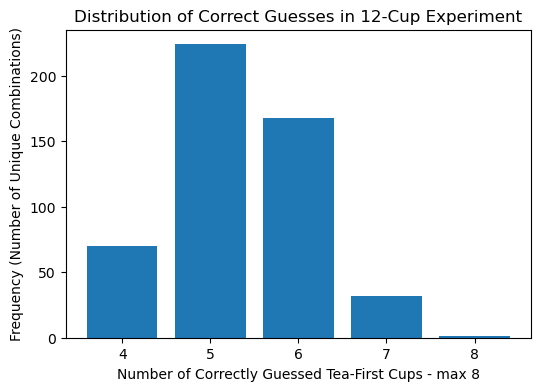

In [666]:
# Create a figure.
# Bar chart where the x-axis is "number of correctly guessed cups"
# and the y-axis is "how many combinations achieve that many correct cups".
fig, ax = plt.subplots(figsize=(6, 4))

# Bar chart.
ax.bar(counts[0], counts[1])

# Set the title for the x-axis 
ax.set_xlabel("Number of Correctly Guessed Tea-First Cups - max 8")

# Set the title for the y-axis 
ax.set_ylabel("Frequency (Number of Unique Combinations)")

# Settitle for the plot
ax.set_title("Distribution of Correct Guesses in 12-Cup Experiment")

plt.show()

The bar chart shows the **exact distribution** of how many tea-first cups a
participant would guess correctly **if they were guessing at random** in the
12-cup version of the Lady Tasting Tea experiment.

There are 12 cups in total, 8 of which are truly tea-first.  
The participant must guess which 8 cups these are.

Because there are $\binom{12}{4} = \mathbf{495}$ possible guesses, and all are equally
likely under random guessing, we can check how many guesses achieve each
possible number of correct cups:

| Correct cups guessed | Count of combinations |
|----------------------|-----------------------|
| 4 | 70 |
| 5 | **224** |
| 6 | 168 |
| 7 | 32 |
| 8 | 1 |


This distribution tell us that **most common random outcome** is getting **5 correct cups**.
This happens in **224 out of 495** possible guesses (about 45%).


What about other probabilities? 

In [667]:
# Calculate the distribution of correct guesses 
total = math.comb(num_cups_ex, num_tea_first_ex)

# check counts for k correct guesses
dist_counts = {}

for k in range(num_tea_first_ex + 1): # k - number of tea-first cups guessed correctly
    
    # the participant is guessing number of tea-first cups correctly
    # if k of them are correct tea-first cups
    # then the remaining (num_milk_first_ex - k) must be milk-first cups guessed correctly

   if 0 <= num_tea_first_ex - k <= num_milk_first_ex:
        dist_counts[k] = (
            math.comb(num_tea_first_ex, k) *
            math.comb(num_milk_first_ex, num_tea_first_ex - k)
        )

# display table
print(f"| {'Correct':^7} | {'Count':^7} | {'Probability':^12} |")
print(f"|{'-'*9}|{'-'*9}|{'-'*14}|")

for k in sorted(dist_counts.keys()): # sort keys in ascending order # https://www.geeksforgeeks.org/python/python-sort-python-dictionaries-by-key-or-value/
    count = dist_counts[k]
    prob = count / total
    print(f"| {k:^7} | {count:^7} | {prob:^12.4f} |") # https://docs.python.org/3/tutorial/inputoutput.html

| Correct |  Count  | Probability  |
|---------|---------|--------------|
|    4    |   70    |    0.1414    |
|    5    |   224   |    0.4525    |
|    6    |   168   |    0.3394    |
|    7    |   32    |    0.0646    |
|    8    |    1    |    0.0020    |


From the distribution we can see that most random guesses stay around the middle values:

- Getting **5 correct** is the most common outcome (224 combinations, about 45%).
- Getting **6 correct** is less common (168 combinations, about 34%).
- Getting **7 correct** is rare (32 combinations, about 6.5%).
- Getting **all 8 correct** is extremely rare  
  (only **1** combination out of 495 ≈ **0.2%**).

Because the participant must identify all **8 tea-first cups** (or equivalently,
all **4 milk-first cups**), these numbers describe exactly what we expect under
the null hypothesis of exact guessing.




Let’s switch everything to the original 8-cup experiment to check the probability 

In [668]:

# Calculate the distribution of correct guesses 
total = math.comb(num_cups, num_tea_first)

# check counts for k correct guesses
dist_counts = {}

for k in range(num_tea_first + 1): # k - number of tea-first cups guessed correctly
    
    # the participant is guessing number of tea-first cups correctly
    # if k of them are correct tea-first cups
    # then the remaining (num_milk_first - k) must be milk-first cups guessed correctly

   if 0 <= num_tea_first - k <= num_milk_first:
        dist_counts[k] = (
            math.comb(num_tea_first, k) *
            math.comb(num_milk_first, num_tea_first - k)
        )

# display table
print(f"| {'Correct - Original'} | {'Count - Original'} | {'Probability - Original'} |")
print(f"|{'-'*20}|{'-'*18}|{'-'*24}|")

for k in sorted(dist_counts.keys()): # sort keys in ascending order # https://www.geeksforgeeks.org/python/python-sort-python-dictionaries-by-key-or-value/
    count = dist_counts[k]
    prob = count / total
    print(f"| {k:^18} | {count:^16} | {prob:^22.4f} |") # https://docs.python.org/3/tutorial/inputoutput.html


| Correct - Original | Count - Original | Probability - Original |
|--------------------|------------------|------------------------|
|         0          |        1         |         0.0143         |
|         1          |        16        |         0.2286         |
|         2          |        36        |         0.5143         |
|         3          |        16        |         0.2286         |
|         4          |        1         |         0.0143         |


##### Comparison with Fisher’s original 8-cup experiment
---

In Fisher’s design (4 milk-first, 4 tea-first):

The chance of a perfect result (4/4) is  
  $
  \frac{1}{\binom{8}{4}} = \frac{1}{70} \approx 1.4\%.
  $

In this extended 12-cup version (4 milk-first, 8 tea-first):

The chance of a perfect result (all 8 tea-first correct) is  
  $
  \frac{1}{\binom{12}{4}} = \frac{1}{495} \approx 0.2\%.
  $


It is **much harder** for a participant to get a perfect score by guessing.

Therefore, a perfect result in the 12-cup version is **even stronger evidence** of real sensitivity to the pouring order than in the 8-cup experiment.

Because the experiment itself is stricter, we do **not** need to relax the usual p-value threshold.

##### Simulation of the 'lady tasting tea' experiment.
---

The function below simulates the experiment under random guessing:

1. Randomly choose which cups are **true tea-first**.
2. Randomly choose which cups the participant **guesses** are tea-first.
3. Count how many of the 8 true tea-first cups were guessed correctly.
4. Repeat this process many times to approximate the distribution of possible outcomes under guessing.

In [669]:
trials = 50000  # number of simulated shuffles
random.seed(42) # for reproducibility

n = num_cups_ex
k = num_tea_first_ex

# Simulation function
def simulate_correct_counts(n, k, trials):
    correct_counts = []  # list to store how many cups are correct each time

    for i in range(trials):
        # 1: Randomly assign which cups are tea first
        true_tea = set(random.sample(range(n), k))

        # 2: Participant randomly guesses which k cups are tea first
        guess_tea = set(random.sample(range(n), k))

        # 3: Count how many cups were guessed correctly
        num_correct = len(true_tea.intersection(guess_tea)) # intersection gives common elements between two sets
        
        # 4: Store the result
        correct_counts.append(num_correct)

    return correct_counts


In [670]:
# Run simulation for both experiments
correct_8 = simulate_correct_counts(num_cups, num_tea_first, trials)
correct_12 = simulate_correct_counts(num_cups_ex, num_tea_first_ex, trials)

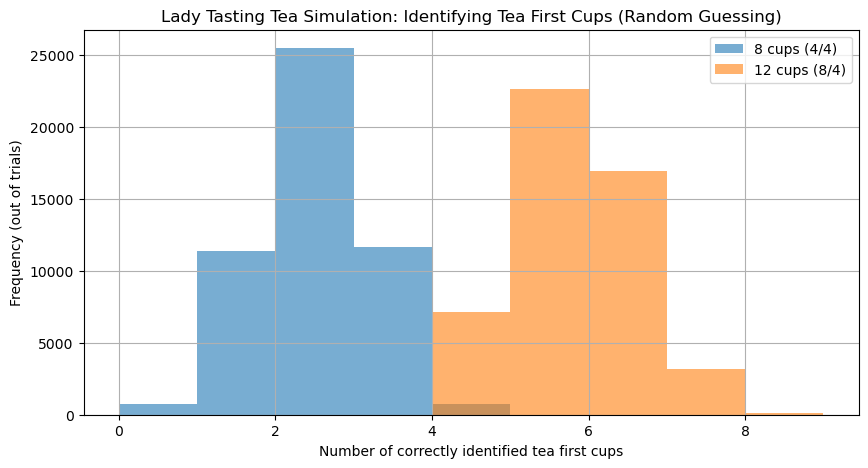

Probability of perfect guessing (8 cups):  0.014380 ≈ 1/70
Probability of perfect guessing (12 cups): 0.142500 ≈ 1/495


In [671]:
# Plot results

plt.figure(figsize=(10, 5))

plt.hist(correct_8, bins=range(num_tea_first + 2), alpha=0.6, label='8 cups (4/4)')
plt.hist(correct_12, bins=range(num_tea_first_ex + 2), alpha=0.6, label='12 cups (8/4)')

plt.xlabel("Number of correctly identified tea first cups")
plt.ylabel("Frequency (out of trials)")
plt.title("Lady Tasting Tea Simulation: Identifying Tea First Cups (Random Guessing)")
plt.legend()
plt.grid(True)
plt.show()


# Print probabilities of perfect guessing
p_all_correct_8 = correct_8.count(num_milk_first) / trials
p_all_correct_12 = correct_12.count(num_milk_first_ex) / trials

print(f"Probability of perfect guessing (8 cups):  {p_all_correct_8:.6f} ≈ 1/{math.comb(8,4)}")
print(f"Probability of perfect guessing (12 cups): {p_all_correct_12:.6f} ≈ 1/{math.comb(12,4)}")



The histogram displays the distribution of correct identifications expected
under random guessing for two experimental designs:

- the **original 8-cup experiment** (4 tea-first / 4 milk-first)  
- the **extended 12-cup experiment**, focusing on identifying **8 tea-first cups**

In both designs, most simulated trials produce **middle-range scores**:

- around **2-3 correct** in the 8-cup version  
- around **5–6 correct** in the 12-cup version  

High scores occur far less frequently, and **perfect scores are extremely rare**.

Let's recap. A perfect result means:

- **4/4 tea-first correct** in the 8-cup test  
- **8/8 tea-first correct** in the 12-cup test  

Under random guessing, these outcomes occur with probabilities:

$
P(\text{perfect in 8 cups}) = \frac{1}{\binom{8}{4}} = \frac{1}{70} \approx 1.4\%
$

$
P(\text{perfect in 12 cups}) = \frac{1}{\binom{12}{4}} = \frac{1}{495} \approx 0.2\%
$

The simulation matches these theoretical values: in tens of thousands of simulated
trials, only a tiny bit can achieve a perfect score.



Because perfect scores are so rare under $(H_0)$, observing one in a real experiment would have an extremely small p-value:

- **8-cup experiment:**  
  $(p \approx 0.014 < 0.05)$ → strong evidence against $(H_0)$

- **12-cup experiment:**  
  $(p \approx 0.002 < 0.01)$ → *even stronger* evidence against $(H_0)$

This allows us to confirm:

* If a participant correctly identifies **all tea-first cups**, this result would be highly unlikely under random guessing.  
* Therefore a perfect score provides strong evidence in favor of $(H_A)$: the participant likely has genuine ability to distinguish the pouring order.




**Conclusion on P-value Threshold Adjustment**

The decision in this hypothesis test is determined by comparing the calculated $p$-value to the predetermined [significance level](https://en.wikipedia.org/wiki/Statistical_significance) (${\alpha}$), typically set at ${0.05}$.

*Interpretation of Results (Extended Design)*

* Observed ${p}$-value (Perfect Score): $\approx{0.002}$ (or $1/495$).
* Decision: Since the $p$-value $(0.002)$ is far below the standard threshold $(\alpha=0.05)$, the result is highly significant.

The probability of a perfect score in the extended design ($\approx 0.20\%$) is seven times smaller than in the original 8-cup design ($\approx 1.43\%$), indicating the test has greater statistical power.

Decision: I would not consider relaxing the $p$-value threshold. Relaxing the threshold (e.g., increasing $\alpha$) would unnecessarily increase the risk of a Type I Error (false positive). 

The [full framework](https://en.wikipedia.org/wiki/Statistical_hypothesis_test) for decision-making based on the Null Hypothesis (${H_0}$) is shown below:

| Decision about $H_0$ | $H_0$ is **True** (Guessing) | $H_0$ is **False** (Has Ability) |
| :---: | :---: | :---: |
| **Not Reject $H_0$** | Correct Inference (True Negative) | **Type II Error** (False Negative, $\beta$) |
| **Reject $H_0$** | **Type I Error** (False Positive, $\alpha$) | Correct Inference (True Positive, $1 - \beta$) 

#### Summary
---


> The simulation shows the range of scores we would expect if the Null Hypothesis **$(H_0)$**
were true, meaning the participant is simply guessing.
> Perfect scores lie at the extreme tail of this distribution, indicating they are highly unlikely under **highly unlikely under $(H_0)$**
> The 12-cup experiment is more demanding than the original design: achieving a perfect score is about seven times less likely than in the 8-cup version when **$(H_0)$** holds. 
> If a participant obtains a perfect score (8/8), this outcome would be very improbable under **$(H_0)$** and therefore provides strong evidence in favor of the Alternative Hypothesis **$(H_A)$** which states that the participant genuinely has the ability to distinguish the pouring order. 


## Problem 2: Normal Distribution

Generate 100,000 samples of size 10 from the standard normal distribution. For each sample, compute the standard deviation with ddof=1 (sample SD) and with ddof=0 (population SD). Plot histograms of both sets of values on the same axes with transparency. Describe the differences you see. Explain how you expect these differences to change if the sample size is increased.

### Solution to the Problem 2
---

The objective of this problem is to simulate the sampling distribution of the standard deviation (SD) using two different formulas: the sample SD sample standard deviation (less biased, uses N−1, based on an unbiased estimator of the variance) and the population SD (biased, uses $N$). I will compare their distributions when drawing small samples ($N=10$) from a known distribution (Standard Normal).

I will be showing the difference between the Sample Standard Deviation and the Population Standard Deviation when calculated from 100,000 of samples drawn from a known population. The intuitive explanation can be found [here](https://stats.stackexchange.com/questions/3931/intuitive-explanation-for-dividing-by-n-1-when-calculating-standard-deviation). 

First, we set up the simulation parameters and generate 100,000 samples from the Standard Normal Distribution ($\mu=0, \sigma=1$). The function used for this is `numpy.random.normal()`.

In [672]:

# parameters
num_samples = 100000 # total number of samples to draw
sample_size = 10 # size of each sample


np.random.seed(50) # for reproducibility

# Generate 100,000 samples, each containing 10 data points, 
# drawn from the standard normal distribution (mean=0, SD=1).
# loc is the mean, scale is the standard deviation
# The resulting array will have shape (100000, 10).
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html
all_samples = np.random.normal(loc=0, scale=1, size=(num_samples, sample_size))


# Show
all_samples


array([[-1.56035211, -0.0309776 , -0.62092842, ...,  1.07026774,
        -1.2822926 , -1.3274789 ],
       [ 0.12633764,  0.86219372,  0.69673696, ...,  0.98777046,
         0.12386626,  0.74278539],
       [-0.39395585,  0.14811582, -0.41223445, ...,  1.71090732,
        -0.14976664,  0.69030672],
       ...,
       [-0.54621149, -0.02158256,  0.50097091, ..., -0.97361894,
        -0.11932131, -0.29581508],
       [ 0.12690568, -1.57630647, -2.68614152, ..., -0.14149786,
        -1.63448757,  0.36346241],
       [ 0.16483063,  0.18183894,  1.1045863 , ..., -0.90203671,
        -0.57977398, -0.05572484]])

These are generated **100,000 independent samples**, each containing **10 data points**, drawn from a Standard Normal distribution (mean = 0, SD = 1). This produces an array called `all samples` with shape *(100000, 10)*, where:

- **Each row (100,000)** represents one sample of size 10.
- **Each column (10 columns in total)** represents one position within the samples.
- In total, the dataset contains **1,000,000 normally distributed values**.

This simulated dataset will be used to study the **sampling distribution of the standard deviation**, comparing:
- the **sample standard deviation** (less biased, uses *N − 1*, based on an unbiased estimator of the variance), and  
- the **population standard deviation** (biased, uses *N*)

#### Sampling Distribution of the Mean and Raw Values
---


Let's check the behavoiur of the individual sampled values (raw data) and the means of each sample (sampling distribution of the mean).
These two distributions illustrate the foundations of sampling theory:

* The raw values follow the distribution of the population 
* The sample means follow a new distribution that becomes narrower as sample size increases.

##### Histogram of Sample Means

Each of the 100,000 samples contains 10 values drawn from $𝑁(0,1)$.


We will check the mean by using [`np.mean`](https://numpy.org/devdocs//reference/generated/numpy.mean.html).


The arithmetic mean is the sum of the elements along the axis divided by the number of elements

In [673]:
# Calculate the means of each sample
means = np.mean(all_samples)  # mean of each sample (along rows)

print(f"the overall mean of all samples is {means}")

the overall mean of all samples is 0.0004849090921235986



Because we have one million values, the mean will be very close to 0.

In [674]:
# how is it look like for each sample
means_samples = np.mean(all_samples, axis=1)  # mean of each sample (along rows)

#print with shape
print(f"the mean of each set is {means_samples} with shape {means_samples.shape} " )


the mean of each set is [-0.50615976  0.71205828  0.15763967 ... -0.31781179 -0.41505048
  0.07291064] with shape (100000,) 


If we compute the mean of each sample, we obtain 100,000 sample means.

Let's plot a histogram:

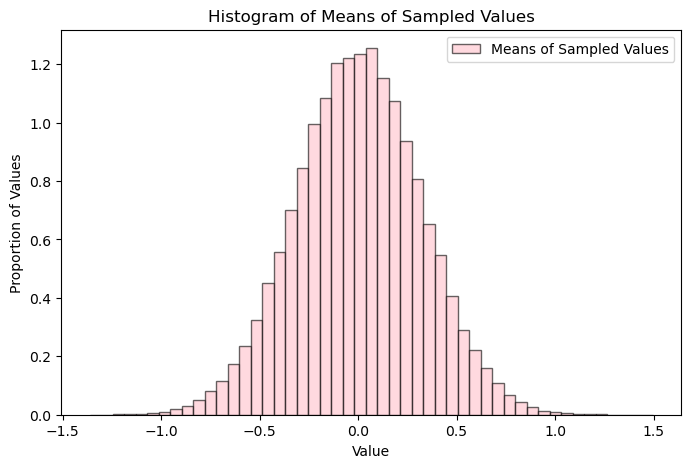

In [675]:
# plot histogram of means of all sampled values


# create figure
fig, ax = plt.subplots(figsize=(8, 5))

# histogram 
ax.hist(means_samples, bins=np.linspace(means_samples.min(), means_samples.max(),50), density=True, alpha=0.6, edgecolor='black', color='pink', label="Means of Sampled Values")


# label the axes and the plot
ax.set_xlabel("Value")
ax.set_ylabel("Proportion of Values")
ax.set_title("Histogram of Means of Sampled Values")
ax.legend()

plt.show()


Each mean is computed from 10 observations drawn from a standard normal distribution $N(0,1)$, the histogram shows the sampling distribution of the mean.

This means the distribution of sample means is:

* Centered at 0 
* Most values between about –0.5 and +0.5
* Very few means beyond –1 and +1

This histogram is an empirical estimate of the [probability density function (PDF)](https://en.wikipedia.org/wiki/Normal_distribution) of the standard normal distribution.

$ f(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} e^{-\frac{(x - \mu)^2}{2 \sigma^2}} $


The above mathematical function can be applied to python: 

In [676]:
def f(x, mu=0.0, sigma=1.0):
  # The normalisation constant.
  norm = 1.0 / np.sqrt(2.0 * np.pi * sigma**2)
  
  # f(x)
  return norm * np.exp(-(x - mu)**2 / (2.0 * sigma**2))

In [677]:
# Test the function.
f(0.0)

0.3989422804014327

In [678]:
# Create an x range.
x = np.linspace(means_samples.min(), means_samples.max(),100000)

# Get y values.
y = f(x, mu=0, sigma=1/np.sqrt(sample_size))


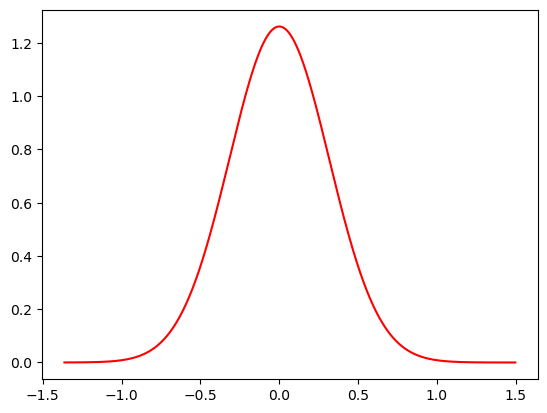

In [679]:
# Create an empty plot.
fig, ax = plt.subplots()

# Plot the function.
ax.plot(x, y, 'r');

Let's plot both together to see how they are overlapping. 

In [680]:
all_samples = np.random.normal(loc=0, scale=1, size=(num_samples, sample_size))

sd_sample = np.std(all_samples, axis=1, ddof=1)
sd_pop    = np.std(all_samples, axis=1, ddof=0)

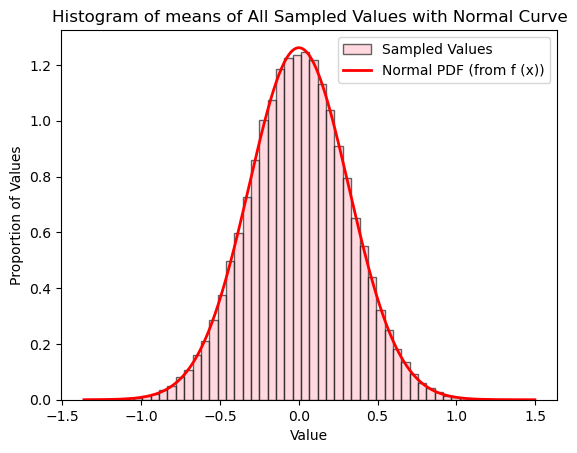

In [681]:

plt.hist(means_samples, bins=np.linspace(means_samples.min(), means_samples.max(), 55), density=True, alpha=0.6, edgecolor="black",
         label="Sampled Values", color='pink')

# x range
x = np.linspace(means_samples.min(), means_samples.max(), 500)
# use the function f()  above
y = f(x, mu=0, sigma=1/np.sqrt(sample_size))

# bell curve 
plt.plot(x, y, 'r-', linewidth=2, label="Normal PDF (from f (x))")

# labels
plt.xlabel("Value")
plt.ylabel("Proportion of Values")
plt.title("Histogram of means of All Sampled Values with Normal Curve")

plt.legend()
plt.show()

The smooth red curve represents the theoretical normal distribution (bell curve) because of its symmetric, bell-shaped form. 

The sample means in the histogram closely follow this bell curve. This happens because each mean is calculated from 10 independent values drawn from a normal distribution.
When we average these values, the distribution of the means becomes more concentrated around the true mean (0) and takes on a normal shape, even more clearly than the raw data.

This alignment between the histogram and the bell curve demonstrates a key idea from statistics:

The sampling distribution of the mean is approximately normal,
It is centered at the population mean, and
It has a smaller spread determined by the standard error 
$\frac{\sigma}{\sqrt{n}}$

##### Histogram of All Sampled Values

Let's look at the distribution of all raw sampled values (1,000,000 numbers total).

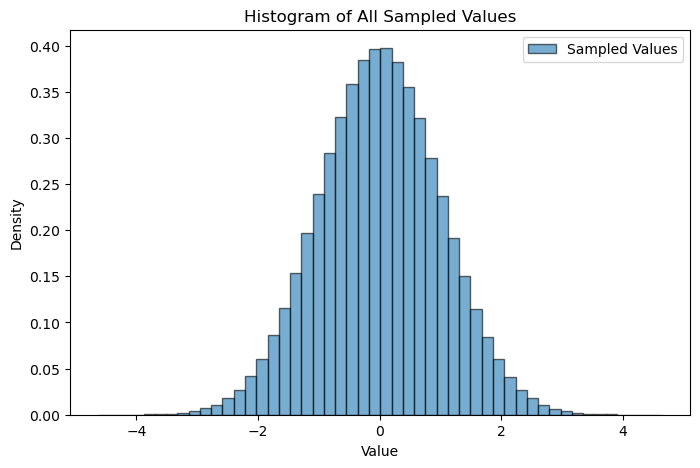

In [682]:
# plot histogram of all sampled values

# flatten the 2D array into 1D 
# for better visualization
flat = all_samples.flatten() # https://www.geeksforgeeks.org/python/flatten-a-matrix-in-python-using-numpy/

# create figure
fig, ax = plt.subplots(figsize=(8, 5))

# histogram 
hist_values = ax.hist(flat, bins=50, density=True, alpha=0.6, edgecolor='black', label="Sampled Values")


# Keep axis labeled
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.set_title("Histogram of All Sampled Values")
ax.legend()

plt.show()

We draw 100,000 samples, each containing 10 values from the [standard normal distribution](https://www.w3schools.com/statistics/statistics_standard_normal_distribution.php)

The histogram shows the distribution of the 1,000,000 individual values generated from a standard normal distribution (mean = 0, SD = 1). Since each of the 100,000 samples contains 10 values from the same normal distribution, flattening them produces a large set of normally distributed numbers. The underlying population we sampled from behaves like a standard normal distribution.

Because the data come from a Normal distribution with parameters $\mu = 0 $ (mean) and $\sigma^2 = 1 $ (standard deviation), the histogram of all sampled values shows the expected
characteristics of a standard normal distribution:


* Centered at 0  
* Most values fall between −1 and +1
* Very few values occur beyond -3 and +3
* Smooth tapering toward the extremes (tail behavior)

A large number of samples makes the histogram closely match the theoretical [bell curve](https://en.wikipedia.org/wiki/Normal_distribution).

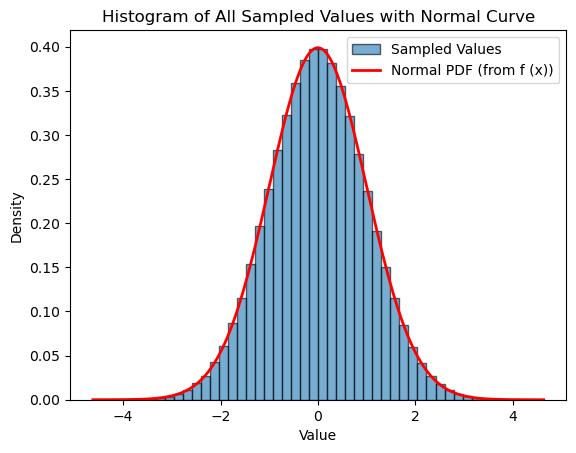

In [683]:
plt.hist(flat, bins=50, density=True, alpha=0.6, edgecolor="black",
         label="Sampled Values")

# x range
x = np.linspace(flat.min(), flat.max(), 500)

# use the function f()  above
y = f(x, mu=0, sigma=1)

# bell curve 
plt.plot(x, y, 'r-', linewidth=2, label="Normal PDF (from f (x))")

# labels
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram of All Sampled Values with Normal Curve")

plt.legend()
plt.show()

The histogram above shows the distribution of all individual values drawn from the standard normal distribution. This histogram is much wider than the earlier histogram of sample means. The reason is that raw observations reflect the full variability of the underlying population. In a standard normal distribution, individual values naturally spread across range -3 to  +3 because each observation is influenced by random noise.

In contrast, the sample means were much more tightly clustered around 0 because averaging 10 values reduces randomness and pulls extreme values toward the center. But individual raw values do not benefit from this averaging effect. Each value is just a single draw from the population, so the variability is much larger.

In summary: Raw values show the true spread of the population, resulting in a wide bell-shaped histogram.

Sample means smooth out randomness, producing a narrow and more stable bell curve.

The difference between the two histograms illustrates how averaging reduces variability, which is why statistical estimates based on means are much more reliable than individual observations.

#### Probability Plots for Raw Sampled Values and Sample Means
---

To check whether our sampled data follow a normal distribution, we can use a probability plot, generated with `scipy.stats.probplot`. (see documentation [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html))<br>
This function compares the ordered values (quantiles) of our sample to the corresponding quantiles of a theoretical normal distribution. If the data come from a normal distribution, the plotted points will fall close to the reference straight line.

Lets check th probability plot for raw sampled values:

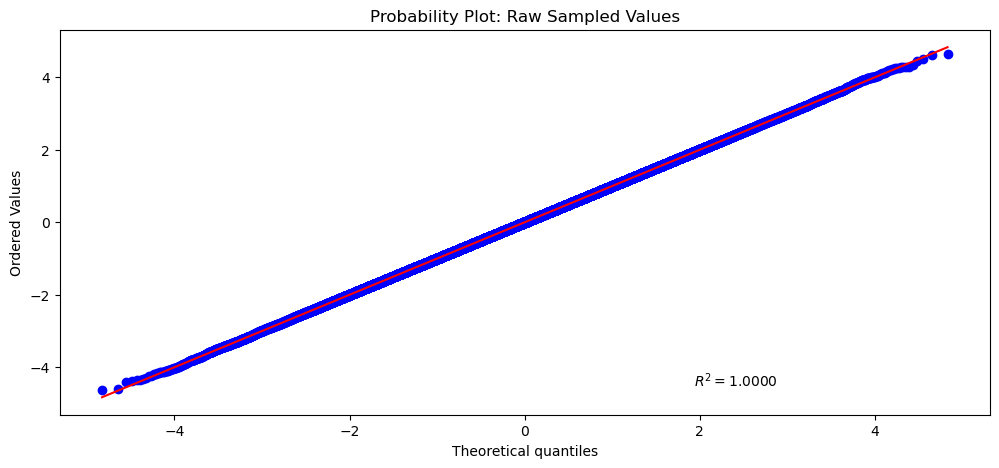

In [684]:
# Probability plot for raw sampled values

plt.figure(figsize=(12, 5))

stats.probplot(all_samples.flatten(), dist="norm", plot=plt, rvalue=True)
plt.title("Probability Plot: Raw Sampled Values")

plt.show()

Now let plot probability for sample means:

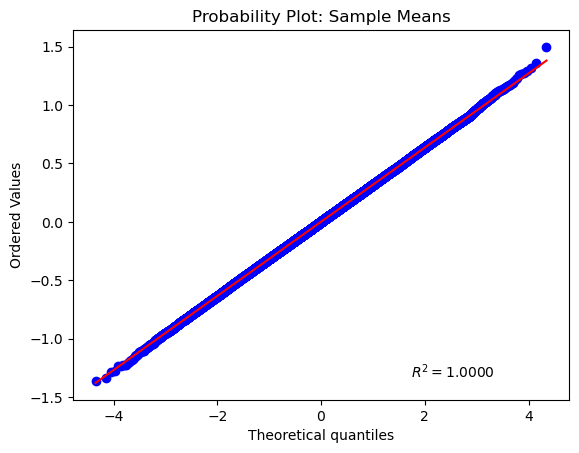

In [685]:
# Probability plot for sample means

stats.probplot(means_samples, dist="norm", plot=plt, rvalue=True)
plt.title("Probability Plot: Sample Means")

plt.show()

Both plots show that the raw sampled values follow the normal distribution well, as expected. The sample means align even more closely with the theoretical normal line, illustrating the [Central Limit Theorem](https://en.wikipedia.org/wiki/Central_limit_theorem): averaging reduces variability and 
produces distributions that are increasingly normal in shape.

$R^2$ represents how well the red line fits the points. The perfect is 1.

Shapiro-Wilk Test

---

The Shapiro–Wilk test checks whether a dataset comes from a normal distribution.
See the documentation [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html#shapiro)

Null hypothesis $(H₀)$: The data are normally distributed.

Alternative $(H₁)$: The data are not normally distributed.

If the p-value is greater than 0.05, we fail to reject $H₀$ → the data are consistent with normality.

If the p-value is less than 0.05, we reject $H₀$ → the data deviate from normality.


It is important to note that for N > 5000, computed p-value may not be accurate, so this test performs better on smaller data. 

In [686]:
# Perform the Shapiro Wilk test for all sampled values.
stats.shapiro(all_samples)

c:\Users\mzare\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 1000000.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=0.9999981396350726, pvalue=0.9999968972560986)

In [687]:
# Perform the Shapiro Wilk test for sample means.
stats.shapiro(means_samples)

c:\Users\mzare\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 100000.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=0.999982676394011, pvalue=0.9627406309038657)

According to Shapiro- Wilk test, both datasets have very high p-values (0.99 for the raw samples and 0.96 for the sample means). 

Since these values are far above 0.05, there is **no evidence to reject the null hypothesis**. 

This means both the raw sampled values and the sample means are consistent with a normal distribution, which is exactly what we expect given how they were generated.

#### Standard Deviation
---



We calculate the standard deviation for every one of the 100,000 samples using the two different formulas provided by the `ddof` [Delta Degrees of Freedom](https://medium.com/@caiocvelasco/degrees-of-freedom-part-2-a-brief-mathematical-introduction-8a8bf5d1dae7) parameter in [NumPy](https://numpy.org/).

DD-OF ${= 1}$ (Sample Standard Deviation) 

The **Sample Standard Deviation ($s$)** is based on an estimator of the variance that is [**unbiased**](https://www.geeksforgeeks.org/machine-learning/unbiased-estimator/), and therefore is typically closer to the true population standard deviation ($\sigma$) than the population SD computed with `ddof=0`, although the SD itself is still slightly biased. 


It uses $N-1$ in the denominator to correct for the tendency of $s$ to underestimate $\sigma$ when calculated from a sample.

`ddof` = 1 ->  Denominator is $N - 1$.

In [688]:
# Calculate Sample Standard Deviation (Sample SD) for all 100,000 samples.
# ddof=1 uses N-1 in the denominator (gives an unbiased estimator of the variance).
sample_sds = np.std(all_samples, axis=1, ddof=1) 



Let's look at the distribution of the Sample Standard Deviation (ddof=1). This allows us to see how it centers around the true value.

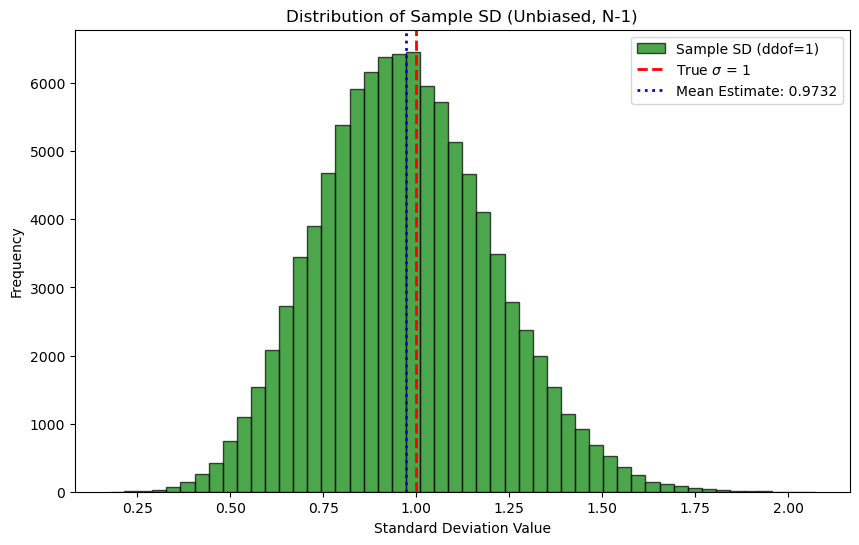

In [689]:
# Plotting histogram for Sample Standard Deviation (ddof=1)

plt.figure(figsize=(10, 6))

# Plot histogram
plt.hist(sample_sds, bins=50, alpha=0.7, color='green', edgecolor='black', label='Sample SD (ddof=1)')

# Plot vertical line for True Sigma (Calculated using 100% of the data in a population)
plt.axvline(1.0, color='red', linestyle='dashed', linewidth=2, label='True $\\sigma$ = 1')

# Plot vertical line for the Mean of the estimations
mean_sample = np.mean(sample_sds)
plt.axvline(mean_sample, color='blue', linestyle='dotted', linewidth=2, label=f'Mean Estimate: {mean_sample:.4f}')

plt.title('Distribution of Sample SD (Unbiased, N-1)')
plt.xlabel('Standard Deviation Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()



DD-OF $\text{= 0}$ (Population Standard Deviation)
The formula for the Population Standard Deviation ($\sigma$) uses $N$ in the denominator. When applied to a sample, this calculation is a biased estimator because it consistently underestimates the true population SD ($\sigma$).$\mathbf{ddof}=0 \rightarrow$ Denominator is $N$.

Now, let's look at the distribution Population Standard Deviation (Population SD) (ddof=0). 

In [690]:
# Calculate Population Standard Deviation (Population SD) for all 100,000 samples.
# ddof=0 uses N in the denominator (biased estimator when applied to a sample).
population_sds = np.std(all_samples, axis=1, ddof=0) 


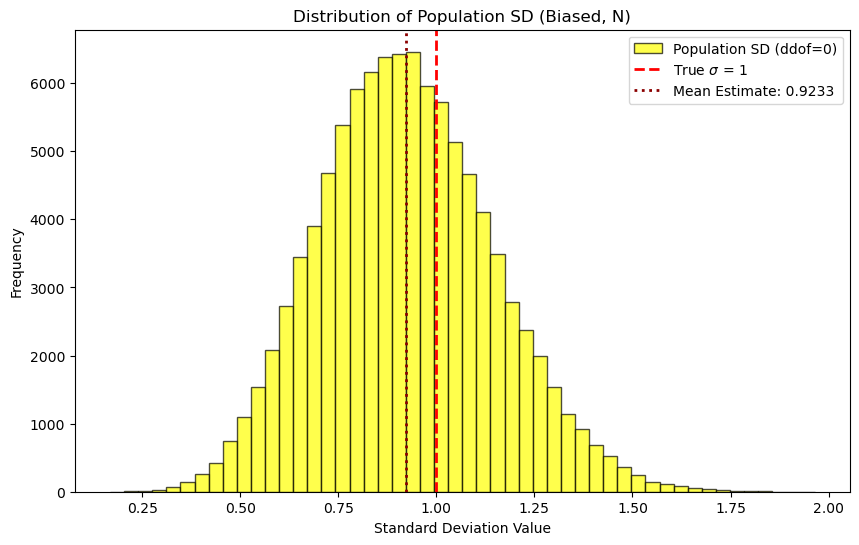

In [691]:
plt.figure(figsize=(10, 6))

# Plot histogram
plt.hist(population_sds, bins=50, alpha=0.7, color='yellow', edgecolor='black', label='Population SD (ddof=0)')

# Plot vertical line for True Sigma (Calculated using 100% of the data in a population)
plt.axvline(1.0, color='red', linestyle='dashed', linewidth=2, label='True $\\sigma$ = 1')

# Plot vertical line for the Mean of the estimations (average value of all the results)
mean_pop = np.mean(population_sds)
plt.axvline(mean_pop, color='darkred', linestyle='dotted', linewidth=2, label=f'Mean Estimate: {mean_pop:.4f}')

plt.title('Distribution of Population SD (Biased, N)')
plt.xlabel('Standard Deviation Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()



Now let's plot the distribution of the 100,000 computed SDs to visually compare the effect of using $N-1$ versus $N$.

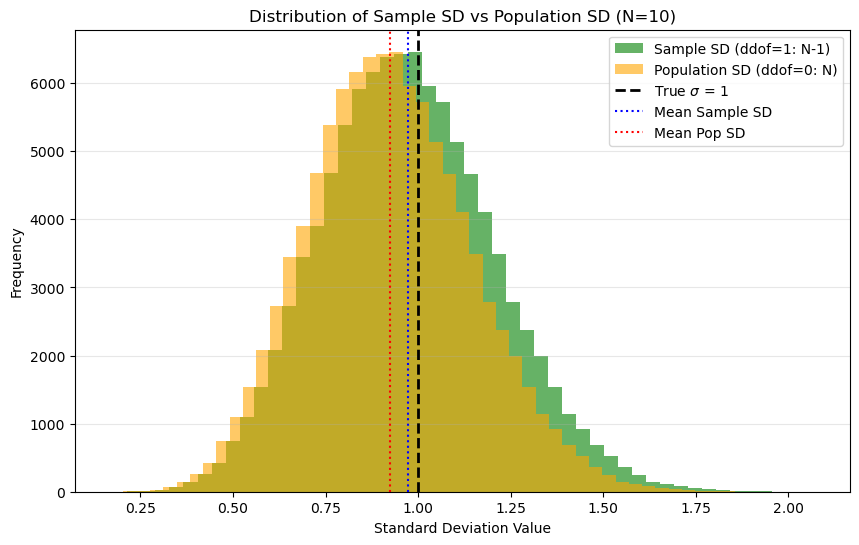

In [692]:
# Calculate SDs
sample_sds = np.std(all_samples, axis=1, ddof=1) # Unbiased-ish (N-1)
population_sds = np.std(all_samples, axis=1, ddof=0) # Biased (N)

# Create the figure
plt.figure(figsize=(10, 6))

# Plot Sample SD (ddof=1)
plt.hist(sample_sds, bins=50, alpha=0.6, color='green', label='Sample SD (ddof=1: N-1)')

# Plot Population SD (ddof=0)
plt.hist(population_sds, bins=50, alpha=0.6, color='orange', label='Population SD (ddof=0: N)')
# Vertical line for True Sigma
plt.axvline(1.0, color='k', linestyle='dashed', linewidth=2, label='True $\\sigma$ = 1')

# Add Mean lines to show the shift
plt.axvline(np.mean(sample_sds), color='blue', linestyle='dotted', label='Mean Sample SD')
plt.axvline(np.mean(population_sds), color='red', linestyle='dotted', label='Mean Pop SD')

plt.title('Distribution of Sample SD vs Population SD (N=10)')
plt.xlabel('Standard Deviation Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


Now, lets increase the sample sizes and see what happens. 

Large Sample (N=100) Results:
Sample SD Mean (ddof=1): 0.99786
Pop SD Mean    (ddof=0): 0.99286
Difference: 0.00500


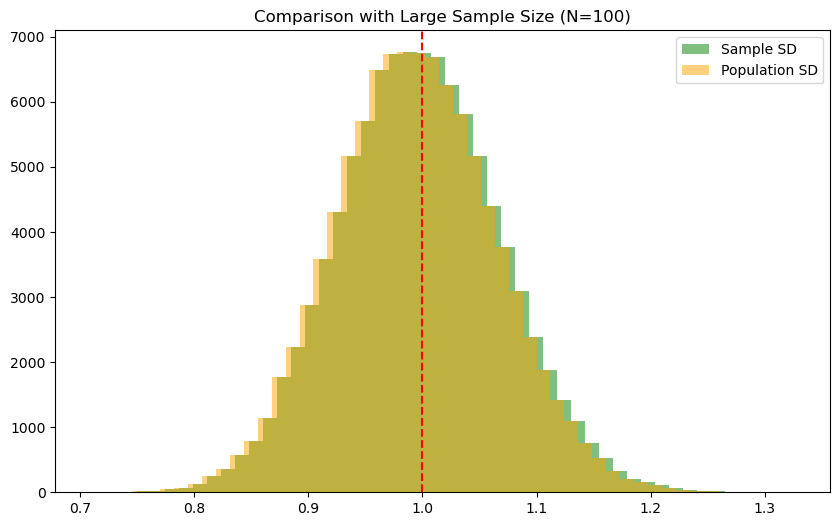

In [693]:
# Now test with a larger sample size 
# 100 data points per sample
N_large = 100
large_samples = np.random.normal(0, 1, size=(100000, N_large))

# Calculate SDs
s_large = np.std(large_samples, axis=1, ddof=1)
p_large = np.std(large_samples, axis=1, ddof=0)

print(f"Large Sample (N={N_large}) Results:")
print(f"Sample SD Mean (ddof=1): {np.mean(s_large):.5f}")
print(f"Pop SD Mean    (ddof=0): {np.mean(p_large):.5f}")
print(f"Difference: {np.mean(s_large) - np.mean(p_large):.5f}")

# Visualizing the Overlap
plt.figure(figsize=(10, 6))
plt.hist(s_large, bins=50, alpha=0.5, color='green', label='Sample SD')
plt.hist(p_large, bins=50, alpha=0.5, color='orange', label='Population SD')
plt.title(f'Comparison with Large Sample Size (N={N_large})')
plt.axvline(1.0, color='red', linestyle='--')
plt.legend()
plt.show()

Now test with an extra large sample size. 

Large Sample (N=1000) Results:
Sample SD Mean (ddof=1): 0.99975
Pop SD Mean    (ddof=0): 0.99925
Difference: 0.00050


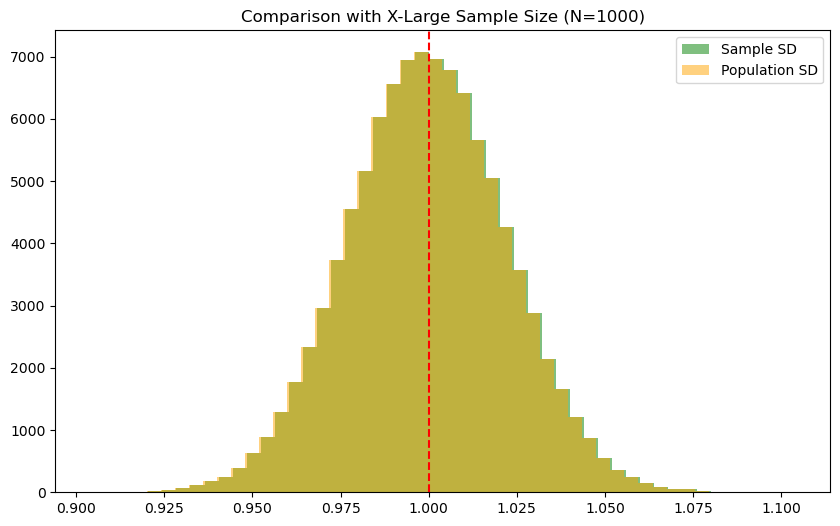

In [694]:

# 1000 data points per sample
N_Xlarge = 1000
large_samples = np.random.normal(0, 1, size=(100000, N_Xlarge))

# Calculate SDs
s_Xlarge = np.std(large_samples, axis=1, ddof=1)
p_Xlarge = np.std(large_samples, axis=1, ddof=0)

print(f"Large Sample (N={N_Xlarge}) Results:")
print(f"Sample SD Mean (ddof=1): {np.mean(s_Xlarge):.5f}")
print(f"Pop SD Mean    (ddof=0): {np.mean(p_Xlarge):.5f}")
print(f"Difference: {np.mean(s_Xlarge) - np.mean(p_Xlarge):.5f}")

# Visualizing the Overlap
plt.figure(figsize=(10, 6))
plt.hist(s_Xlarge, bins=50, alpha=0.5, color='green', label='Sample SD')
plt.hist(p_Xlarge, bins=50, alpha=0.5, color='orange', label='Population SD')
plt.title(f'Comparison with X-Large Sample Size (N={N_Xlarge})')
plt.axvline(1.0, color='red', linestyle='--')
plt.legend()
plt.show()

#### Summary

Observed Differences in Histograms

---

>When observing the plot, the key difference is the central tendency of the two distributions:
Population SD (ddof=0): This distribution is moved slightly to the left (lower values). Its mean is less than the true population standard deviation ($\sigma=1$). 
This demonstrates that using $N$ in the denominator results in a biased estimator that keeps underestimating the true population SD when applied to small samples.<br>
Sample SD `ddof=1`: This distribution is shifted slightly to the right (higher values) compared to the `ddof=0` distribution. 
Its mean is much closer to the true population standard deviation ($\sigma=1$). <br>
This confirms that the [Bessel's correction](https://www.geeksforgeeks.org/machine-learning/bessels-correction/) (using $N-1$) reduces the bias in the SD estimate (and makes the variance estimate unbiased).  
For more explanation see the youtube video [here](https://www.youtube.com/watch?v=E3_408q1mjo). <br>
If we significantly increase the sample size from $N=10$ to $N=1000$, we expect two major changes in the plots:
**The Two Histograms Will Merge (two histograms look almost the same)**
The only difference between the two calculations is whether we divide by **$N$** (Population formula) or **$N-1$** (Sample formula). <br>
**Small Sample ($N=10$):** Dividing by 10 versus 9 makes a big difference (about 11%). This pushes the histograms apart.<br>
**Large Sample ($N=1000$):** Dividing by 1000 versus 999 makes almost no difference ( as only about 0.1%). <br>
Because the mathematical difference becomes tiny, the "Population SD" histogram will slide over and sit almost perfectly on top of the "Sample SD" histogram.
Using more data ($N=1000$) makes the math correction ($N-1$) less important, and the estimates become more precise.


## Problem 3: t-Tests

A type II error occurs when a test fails to reject the null hypothesis even though it is false. For each mean difference
$ d =0,0.1,0.2,…,1.0 $, repeat the following simulation 1,000 times:


* Draw two samples of size 100, one from the standard normal distribution and one from the normal distribution with mean $d$ and standard deviation 1.
* Run an independent samples t-test on the two samples, rejecting the null hypothesis if the p-value is less than 0.05.
* Record the proportion of times the null hypothesis is not rejected.


Plot this proportion against $d$, and explain how the type II error rate changes as the difference in means increases.

### Solution to the Problem 3
---

In this problem, I will simulate two independent samples for a range of mean differences $d$ and perform an independent-samples t-test for each simulated pair. For every value of $d$, I will repeat the process 1,000 times and record how often the test fails to reject the null hypothesis, which represents the Type II error rate. I will then plot these error rates against $d$ to observe how the ability of the t-test to detect a true difference improves as the mean separation increases.

#### Type II Error and Mean Difference

A type II error occurs when a test fails to reject the null hypothesis even though it is false. In this problem, we investigate how the type II error rate changes as the difference in means between two populations increases.
See more information [here](https://www.scribbr.com/statistics/type-i-and-type-ii-errors/).





<img src="https://github.com/mondbr/applied_statistics/blob/main/images/error_types.png" width=20% height=20%>

For each mean difference $d = 0, 0.1, 0.2, \dots, 1.0 $, we repeat the following simulation 1,000 times:

- Draw two samples of size 100 of two normal populations:
   - Groupa A from $N(0, 1)$
   - Group B from $N(d, 1)$
- Run an independent samples t-test on the two samples.
- Reject the null hypothesis $H_0: \mu_1 = \mu_2$ if the p-value is less than 0.05.
- Record whether the test **fails to reject** the null hypothesis.

For each value of $d$, we compute the **proportion of simulations where the null hypothesis is not rejected**. When $d > 0 $, this proportion estimates the **type II error rate** (the probability of failing to detect a  difference). When $d = 0$, the null hypothesis is true, so this proportion is expected to be close to $1-\alpha$ and does not represent a Type II error.

We then plot this proportion against $d$ and interpret how the type II error rate changes as the true difference between the means increases.


In this simulation the populations are normal and have equal variances by construction. 

Let's set up parameters:

In [695]:
np.random.seed(100)

# Parameters
n= 100  # sample size per each group
n_simulations = 1000  # for each value of d, repeat the experiment 1,000 times
alpha = 0.05  # threshold for rejecting the null hypothesis in the t-test
sigma = 1  # both populations have standard deviation 1
mu_a = 0  # mean of group A drawn from N(0,1)
# mu_b = d # mean of group B depends on d


ds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] # mean differences


#### Example: Visualising Two Samples for One Value of d

Before running the full simulation, I will generate one example pair of samples using a fixed difference $d = 0.9$.  
This plot is to illustrate how two samples drawn from normal distributions with a substantial difference in means appear, and why the t-test is able to detect this difference with high probability.

In [696]:
# example for plotting
# example value of d: d is the mean difference between group A and group B test
d_example = 0.9
mu_b_example = mu_a + d_example

Generate samples for group A and group B test:

In [697]:
# Generate samples for group A and group B test
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html
# loc is the mean, scale is the standard deviation


group_a = np.random.normal(loc=mu_a, scale=sigma, size=n) # generate group A random sampleof size 100 from N(0,1).


group_b_example = np.random.normal(loc=mu_b_example, scale=sigma, size=n) # testing for generating group B random 


I am setting `d_example = 0.9`, calculate `mu_b_example` as `mu_a + d_example`, and then generate `group_b_example` from $N(μ_B,σ=1)$, so that group **B_example** sample has a mean 0.9 units higher than group A to illustrate a specific mean difference in the simulation.

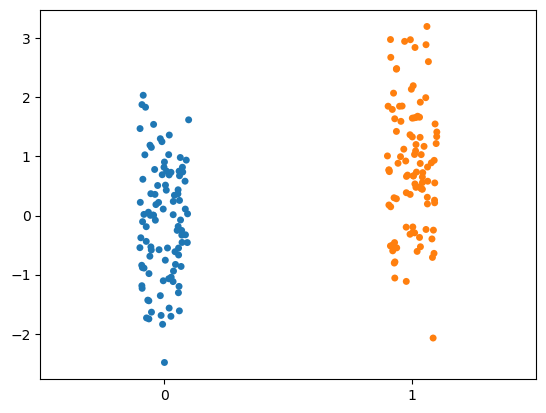

In [698]:
# Create a strip plot for fixed d = 0.9.

# https://seaborn.pydata.org/generated/seaborn.stripplot.html
sns.stripplot(data=[group_a, group_b_example]);

The strip plot shows two independent samples drawn from normal distributions with equal variance but different means. Group A is centered around 0, while Group B_example is centered around 0.9, resulting in a noticeable separation between the two groups. Although there is still some overlap due to random variation, the shift in the center of **Group B_example** is clearly visible.



Let's run a independent-samples t-test now to demonstrate what happens for example of $d=0.9$. 

I will use [`scipy.stats.ttest_ind`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html#ttest-ind)

Remembering that **Null Hypothesis:** is that the population means are equal.

In [699]:
# Perform a t-test.
stats.ttest_ind(group_a, group_b_example)

TtestResult(statistic=-6.454529288211138, pvalue=8.183565006976587e-10, df=198.0)

In [700]:
# Perform t-test
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

t_stat, p_value = stats.ttest_ind(group_a, group_b_example)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.12f}")

if p_value < alpha:
    print("Reject H0 (means are different).")
else:
    print("Fail to reject H0.")

t-statistic: -6.4545
p-value: 0.000000000818
Reject H0 (means are different).


The t-test shows a large-magnitude test statistic (t=−6.4545) and an extremely small p-value (p=0.000000000818).
This indicates very strong evidence against the null hypothesis of equal means. At the significance level 
$α=0.05$, we reject $H_0$ and can conclude that the two population means are different.

The large absolute value of the t-statistic arises because the true mean difference (d=0.9) is large relative to the within-group variability, making it very unlikely to observe such a difference under the null hypothesis. This result is consistent with the simulation findings, where the Type II error rate approaches zero for large values of d.


The visual separation above explains why the independent-samples t-test has high power for $d=0.9$. The difference in means is large relative to the within-group variability, making it unlikely that the test will fail to reject the null hypothesis. This corresponds to the very low Type II error rate observed for larger values of $d$ in the simulation.

Let's see a box plot:

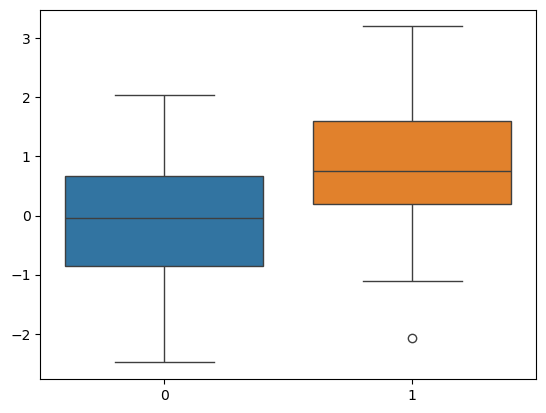

In [701]:
# box plot
# https://seaborn.pydata.org/generated/seaborn.boxplot.html
sns.boxplot(data=[group_a, group_b_example]);

The box plot compares the distributions of Group A and Group B test for a mean difference of 
$d=0.9$. Group B test (orange) is visibly shifted upward relative to Group A, as shown by a higher median and higher quartiles. This confirms that the difference in means is not driven by a few extreme values but reflects a consistent shift across the entire distribution.

**Independent Samples t-test (Single Run)**

---

We run one independent-samples t-test for the example samples above. 

In [702]:
# independent t-test
t_stat, p_value = stats.ttest_ind(group_a, group_b_example) # t_stat measures how far apart the sample means are relative to the variability in the data
t_stat, p_value # probability of observing a t-statistic at least this extreme if the null hypothesis were true.

(-6.454529288211138, 8.183565006976587e-10)

This code runs an independent-samples t-test and stores the resulting t-statistic and p-value, which are used to decide whether the group means differ significantly.

A large absolute value of `t_stat` indicates a large difference between group means relative to variability. The negative sign reflects the order of subtraction (the mean of `group_b_example` is larger than the mean of `group_a`).


The extremely small p-value shows that the probability of observing such a large difference under the null hypothesis of equal means is almost zero. At the significance level  $α=0.05$, we strongly reject the null hypothesis and conclude that the two group means are statistically different.

Because the decision of the t-test depends not only on the observed test statistic but also on the shape of the reference distribution, we next consider the degrees of freedom associated with the test. The degrees of freedom determine which t-distribution is used to compute the p-value and critical values. 

This allows us to verify that the t-distribution used in the test is consistent with the sample sizes in our simulation.

For an independent-samples [Student t-test](https://en.wikipedia.org/wiki/Student%27s_t-test) with equal variances, the degrees of freedom depend directly on the sample sizes of the two groups.

For our samples  with $n=100$ each, the degrees of freedom for the Student t-testis calculated as: $df = n + n - 2$

In [703]:
# degrees of freedom
df = 2*n - 2

print (f"Degrees of Freedom: {df}")

Degrees of Freedom: 198


This is matching exaclty our df value in t-test above. 

Once the degrees of freedom are known, we can identify the critical t-values that define the rejection regions of the test. For a two-sided test with significance level $α=0.05$, the rejection region is split evenly between the lower and upper tails of the t-distribution. This places $α/2=0.025$ in each tail, and the corresponding critical values are obtained from the t-distribution with 198 degrees of freedom.

Let's calculate that:

For a two-sided hypothesis test with significance level $α=0.05$, the rejection region is split evenly between the two tails of the t-distribution:

In [704]:
# critical t-values for two-tailed test
# left_critical = stats.t.ppf(
alpha / 2

0.025

In [705]:
# second critical value
# right_critical = stats.t.ppf(
1 - alpha / 2

0.975

At $\alpha=0.05$ (two-sided), the critical values are the 2.5% and 97.5% quantiles of the t-distribution.

After determining the degrees of freedom, the next step is to identify the critical t-values that define the rejection regions of the hypothesis test. Using the degrees of freedom and significance level, we now compute the left and right critical t-values that define the rejection regions of the two-sided t-test.

In [706]:
# critical t-values for two-tailed test

left_critical = stats.t.ppf(alpha / 2, df)
right_critical = stats.t.ppf(1 - alpha / 2, df)

left_critical, right_critical

(-1.972017477833896, 1.9720174778338955)

In [707]:
# the same critical values can be obtained directly as follows:
stats.t.ppf(0.025, df=198), stats.t.ppf(0.975, df=198)

(-1.972017477833896, 1.9720174778338955)

Let's plot it:

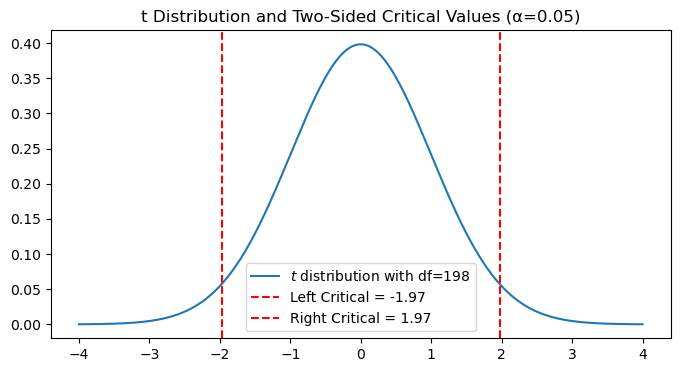

In [708]:
# Plot the t-distribution and critical values

x = np.linspace(-4, 4, 1000)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, stats.t.pdf(x, df), label=fr"$t$ distribution with df={df}")
ax.axvline(left_critical, color="red", linestyle="--", label=f"Left Critical = {left_critical:.2f}")
ax.axvline(right_critical, color="red", linestyle="--", label=f"Right Critical = {right_critical:.2f}")

ax.set_title("t Distribution and Two-Sided Critical Values (α=0.05)")
ax.legend()
plt.show()


The curve shows the t-distribution with $df=198$ while the red dashed lines mark the two-sided critical values at 
$𝛼=0.05$. Any test statistic falling beyond these boundaries lies in the rejection region and leads to rejection of the null hypothesis. This visualisation highlights how statistical significance is determined by comparing the observed t-statistic to these critical thresholds.

With this decision rule established, I now proceed to the full simulation to estimate the Type II error rate and check how often the test fails to reject the null hypothesis—across different values of the true mean difference d. 

It is important to note that the curve shown above is not a normal (Gaussian) distribution, but a Student’s t-distribution. While the t-distribution is symmetric and bell-shaped like the normal distribution, it has heavier tails, reflecting greater uncertainty when estimating variability from finite samples.

The two red dashed lines represent the critical values obtained from the percent point function (PPF) of the t-distribution, which gives the quantiles corresponding to the chosen significance level. These values depend on the degrees of freedom and are therefore specific to this test setup. As the sample size increases and the degrees of freedom grow, the t-distribution gradually approaches the normal distribution.

Reference: https://www.w3schools.com/statistics/statistics_students_t_distribution.php

#### Simulation: Estimate Type II Error Rate for Each d

Now, let's move to the actual problem. 

Using $α=0.05$ as our decision threshold, we now simulate the experiment 1,000 times for each 
$𝑑$ and record how often the t-test fails to reject $H_0$. This proportion estimates the Type II error rate for each mean difference.

In [709]:
type2_rates = []   # proportion of "fail to reject" for each d

for d in ds:
    fail_to_reject = 0
    mu_b = mu_a + d   # mean of group B for this value of d
    
    for _ in range(n_simulations):
        group_a = np.random.normal(loc=mu_a, scale=sigma, size=n) # group A from the beggining setup parameters
        group_b = np.random.normal(loc=mu_b, scale=sigma, size=n) # group B with mean shifted by d

        # Independent samples t-test (Student)
        _, p_value = stats.ttest_ind(group_a, group_b, equal_var=True) # "_" is used to ignore the t-statistic output

        # Fail to reject if p >= alpha
        if p_value >= alpha:
            fail_to_reject += 1

    type2_rates.append(fail_to_reject / n_simulations)

type2_rates

[0.958, 0.898, 0.727, 0.448, 0.217, 0.074, 0.007, 0.002, 0.0, 0.001, 0.0]

Let's plot the results: 

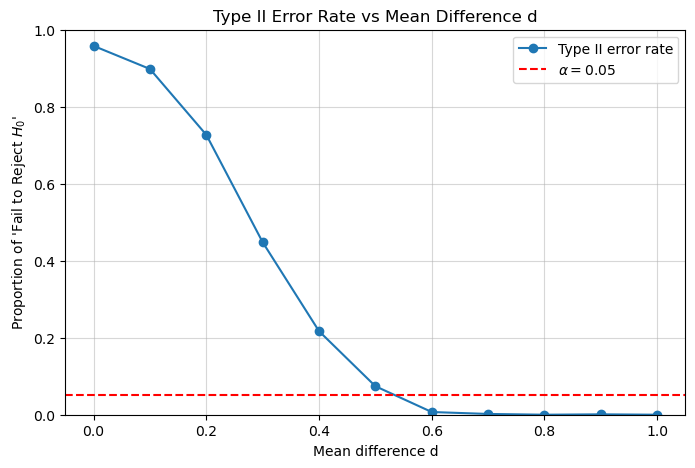

In [710]:
plt.figure(figsize=(8, 5))
plt.plot(ds, type2_rates, marker='o', label='Type II error rate')
plt.axhline(y=alpha, color='red', linestyle='--', label=r'$\alpha = 0.05$')

plt.title("Type II Error Rate vs Mean Difference d")
plt.xlabel("Mean difference d")
plt.ylabel("Proportion of 'Fail to Reject $H_0$'")
plt.ylim(0, 1)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

The dashed horizontal line represents the significance level $α=0.05$, included as a reference to contrast the fixed Type I error rate with the decreasing Type II error rate as the mean difference $d$ increases. 

#### Summary 

> In this problem, we used simulation to study how the **Type II error rate** of an independent-samples t-test depends on the true difference in means between two populations. For each mean difference $d = 0, 0.1, 0.2, \dots, 1.0 $,  we repeatedly generated two independent samples of size n=100 from normal distributions with equal variance and performed a two-sided t-test at significance level 
$α=0.05$. The proportion of simulations in which the null hypothesis was not rejected provided an estimate of the Type II error rate $β$.<br>
The results show a clear decreasing relationship between the Type II error rate and the mean difference d. When 
d is close to zero, the two populations are nearly indistinguishable, and the test frequently fails to detect a difference, resulting in a high Type II error rate. As d increases, the separation between the population means becomes larger relative to the within-group variability, making it easier for the t-test to detect the difference. 
Consequently, the Type II error rate rapidly decreases and approaches zero for larger values of d.<br>
Overall, this simulation demonstrates that the power of a statistical test $(1−β)$ increases as the effect size grows. While the significance level $α$ controls the probability of a Type I error and remains fixed, the Type II error rate is strongly influenced by the magnitude of the true mean difference, highlighting the importance of effect size and sample size in hypothesis testing.

## Problem 4: ANOVA

Generate three independent samples, each of size 30, from normal distributions with means 0, 0.5, and 1, each with standard deviation 1.

* Perform a one-way ANOVA to test whether all three means are equal.
* Perform three independent two-sample t-tests: samples 1 vs 2, 1 vs 3, and 2 vs 3.
* Compare the conclusions.

Write a short note on why ANOVA is preferred over running several t-tests.

### Solution to the problem 4

---

In this problem, I will generate three independent samples (n=30 each) from normal distributions:

- Sample 1: $N(0, 1)$
- Sample 2: $N(0.5, 1)$
- Sample 3: $N(1, 1)$

I will first run **pairwise two-sample t-tests** (1 vs 2, 1 vs 3, 2 vs 3) to see which group means appear different.  
Then I will run a **one-way ANOVA** to test whether all three means are equal, and use **Tukey’s HSD** as a post-hoc test to compare groups while controlling for multiple comparisons.

**What is ANOVA?**

To compare more than two groups we use ANOVA (analysis for variance). 
One-Way ANOVA is a statistical test used to check if there are significant differences between the means of three or more groups i.e analysis of variance. It helps us to find whether the variations in data are due to different treatments or random chance. 

See the documentation [here](https://www.geeksforgeeks.org/python/how-to-perform-a-one-way-anova-in-python/).

Let's set a random seed for reproducibility and generate three independent samples of size $n=30$. 
Each sample comes from a normal distribution with standard deviation 1 but different means ($\mu_1, \mu_2, \mu_3$ \) as (0, 0.5, and 1).

In [711]:
# Set random seed for reproducibility
np.random.seed(555)


# set parameters

n=30
sigma=1
mu_1=0
mu_2=0.5
mu_3=1
alpha=0.05



Now, I will generate data for three samples.  

In [712]:
# Generate data for three groups
# loc is the mean, scale is the standard deviation

# first sample
sample_1 = np.random.normal(loc=mu_1, scale=sigma, size=n)

# second sample
sample_2 = np.random.normal(loc=mu_2, scale=sigma, size=n)

# third sample
sample_3 = np.random.normal(loc=mu_3, scale=sigma, size=n)



Checking the mean of each sample:

In [713]:
# Show means of each sample
np.mean(sample_1), np.mean(sample_2), np.mean(sample_3)

(0.047940931787537625, 0.44768382954633473, 1.1060302718909185)

The sample means are close to the true population means (0, 0.5, and 1), with small deviations due to random sampling variability. This confirms that the data were generated correctly and that the three groups differ in their central tendency.

Let's visualise the data. 

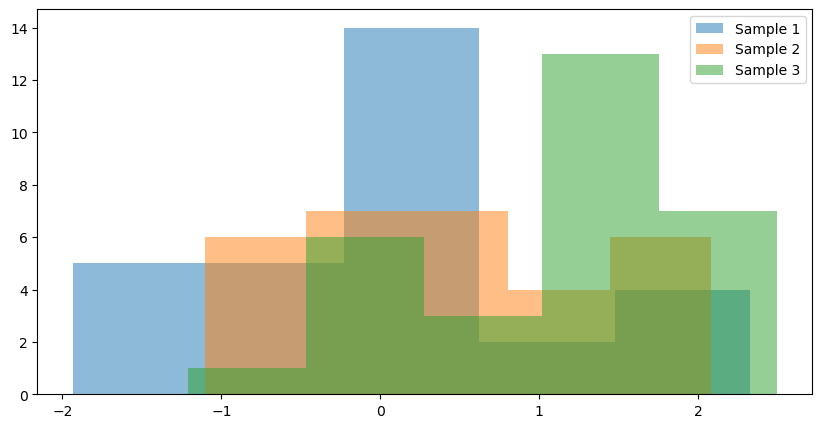

In [714]:
# Create histograms.
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram of the first sample.
ax.hist(sample_1, bins=5, alpha=0.5, label='Sample 1')

# Histogram of the second sample.
ax.hist(sample_2, bins=5, alpha=0.5, label='Sample 2')

# Histogram of the third sample.
ax.hist(sample_3, bins=5, alpha=0.5, label='Sample 3')

# Add a legend.
ax.legend();

The overlaid histograms show the distributions of the three samples drawn from normal populations with different means. The histograms show that all three samples have a similar spread but are centered at different values. As the mean increases from Sample 1 to Sample 3, the distributions shift to the right. There is noticeable overlap between the samples, which suggests that statistical tests are needed to determine whether the mean differences are significant.

Let's see the box plot for better visibility. 

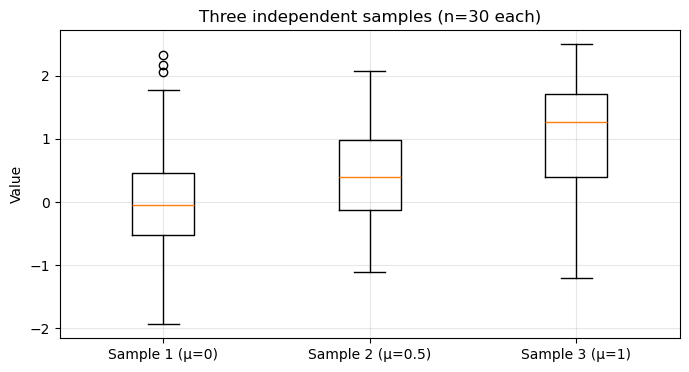

In [715]:
# create box plot
plt.figure(figsize=(8, 4))
plt.boxplot([sample_1, sample_2, sample_3], tick_labels=["Sample 1 (μ=0)", "Sample 2 (μ=0.5)", "Sample 3 (μ=1)"])
plt.title("Three independent samples (n=30 each)")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.show()


The box plots show increasing medians from Sample 1 to Sample 3, reflecting the increasing population means. The spreads are similar across groups, indicating comparable variability. Although the groups overlap, the differences in central location suggest that the means may not be equal.



#### Pairwise two-sample t-tests (independent)**

Since there are three independent samples, there are three possible pairwise comparisons. Using combinations we can confirm that the pairs are (Sample 1 vs 2), (Sample 1 vs 3), and (Sample 2 vs 3). This matches the combinatorial result of 3, meaning three independent two-sample t-tests are required to compare all groups pairwise.

In [716]:
# number of samples
num_samples = 3

In [717]:
# show the sample labels
print(list(range(num_samples)))

[0, 1, 2]


In [718]:
# for 3 samples we need to perform 3 t-tests
# show all pairwise combinations of sample indices
list(it.combinations(range(num_samples), 2))

[(0, 1), (0, 2), (1, 2)]

In [719]:
# pair of samples to compare
math.comb(num_samples, 2)

3

Running first t-test result: 

In [720]:
# perform  1st t-test between sample 1 and sample 2
stats.ttest_ind(sample_1, sample_2)

TtestResult(statistic=-1.5674515261772208, pvalue=0.12244933200376173, df=58.0)

The independent samples t-test between Sample 1 and Sample 2 produces a p-value of approximately 0.12, which is greater than α = 0.05. 
Therefore, we should fail to reject the null hypothesis. Although we know that the population means are different by design, the sample size is small and the samples overlap, so the t-test does not provide enough evidence to detect a difference in this case.

Running second t-test result: 

In [721]:
# perform 2nd t-test between sample 1 and sample 3
stats.ttest_ind(sample_1, sample_3)

TtestResult(statistic=-4.149188622358103, pvalue=0.00011047685691976173, df=58.0)

The independent samples t-test between Sample 1 and Sample 3 produces a very small p-value (p < 0.001), which is below α = 0.05. Therefore, we should reject the null hypothesis and conclude that there is a statistically significant difference between the means of Sample 1 and Sample 3 which align with our initial parameters setup. 

Running third t-test: 

In [722]:
# perform 3rd t-test between sample 2 and sample 3
stats.ttest_ind(sample_2, sample_3)

TtestResult(statistic=-2.919271896400341, pvalue=0.004987770707809573, df=58.0)

The independent samples t-test between Sample 2 and Sample 3 produces a p-value of approximately 0.005, which is less than α = 0.05. Therefore, we reject the null hypothesis and conclude that there is a statistically significant difference between the means of Sample 2 and Sample 3.


The three pairwise t-tests lead to mixed conclusions. 
While the comparison between Sample 1 and Sample 2 does not show a statistically significant difference, both *Sample 1 vs Sample 3* and *Sample 2 vs Sample 3* t-tests do. 

Running multiple t-tests increases the risk of false positive results and makes interpretation less straightforward. 

This motivates the use of a one-way ANOVA, which tests for differences among all group means simultaneously while controlling the overall [Type I error rate](https://www.geeksforgeeks.org/data-science/type-i-and-type-ii-errors/).

We can quickly demonstrate the meaning of the significance level $\alpha $.  
A **Type I error** happens when we reject the null hypothesis even though it is true.  

If we repeatedly generate two samples from the same population and run a t-test at $\alpha=0.05$, we expect to reject $H_0$ about 5% of the time purely by chance.

The code below simulates this by running many t-tests and counting how often the p-value falls below $\alpha$.

In [723]:
# means under null hypothesis
mu_1_t = 0 # must be equal to mu_2 under null hypothesis
mu_2_t = 0 # null hypothesis: no difference in means

In [724]:
def simulate_ttest(alpha):
    # Generate two samples from the same population
    sample_a = np.random.normal(loc=mu_1_t, scale=sigma, size=n)
    sample_b = np.random.normal(loc=mu_2_t, scale=sigma, size=n)

    # Perform independent samples t-test
    _, p_value = stats.ttest_ind(sample_a, sample_b) # "_" is used to ignore the t-statistic output

    # Decide whether to reject the null hypothesis.
    if p_value < alpha:
        return True
    else:
        return False

In [725]:
# Number of rejections.
no_rejections = 0

# Run several simulations.
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if simulate_ttest(alpha):
        # Increment the number of rejections.
        no_rejections += 1

# Show the number of rejections.
no_rejections

469

Checking the proportion of rejections in number of simulations: 

In [726]:
no_rejections / 10000 # proportion of rejections

0.0469

We correctly set means `mu_1_t` = `mu_2_t` = 0, so the null hypotesis is **true** by construction. We repeatedly run an independent samples t-test and count how often $H_0$ is rejected. With $\alpha = 0.05$ and 10,000 simulations, we are getting 492 rejections which is $\approx 5%$ of the total number of simulations.

This confirms that the Type I error rate is controlled by $\alpha$ and matches the theory. 

We can also visualise the distribution of p-values to better understand Type I errors.

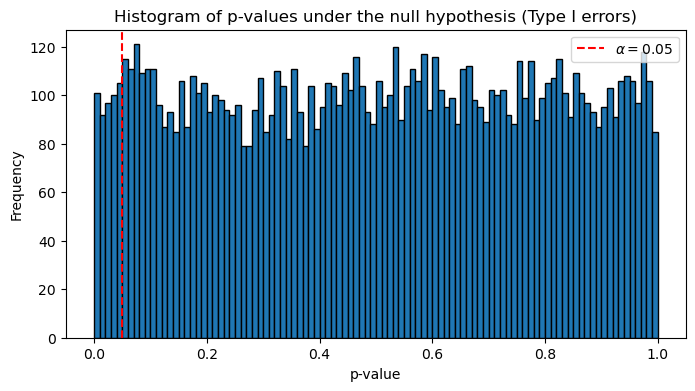

In [727]:
# Store p-values
p_values = []

for _ in range(10000):
    sample_a = np.random.normal(loc=mu_1_t, scale=sigma, size=n)
    sample_b = np.random.normal(loc=mu_2_t, scale=sigma, size=n)
    
    _, p_value = stats.ttest_ind(sample_a, sample_b)
    p_values.append(p_value)

# Plot histogram of p-values
plt.figure(figsize=(8, 4))
plt.hist(p_values, bins=100, edgecolor='black')
plt.axvline(alpha, color='red', linestyle='--', label=r'$\alpha = 0.05$')
plt.title("Histogram of p-values under the null hypothesis (Type I errors)")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.legend()
plt.show()



The histogram shows the distribution of p-values when the null hypothesis is true. The approximately uniform shape confirms the expected behavior of p-values under the null. The vertical line at α = 0.05 marks the rejection threshold, and about 5% of the p-values fall to the left of this line, illustrating the Type I error rate.

We can also do an additional simulation to illustrate a key problem with doing many pairwise t-tests.

Here the three populations have different means by construction $\mu_1=0$, $mu_2=0.5$, $\mu_3=1$.

In each simulation, I generate three samples and run the three pairwise independent t-tests (1 vs 2, 1 vs 3, 2 vs 3).  

Instead of counting every rejection separately, I record whether **at least one** of the t-tests rejects $H_0$ at $\alpha=0.05$.

This gives the proportion of simulations where the set of t-tests finds *some* evidence of a difference.

In [728]:
# Simulation function for three t-tests
def simulate_three_ttest(alpha):
    # Geneate a random sample a.
    sample_a = np.random.normal(loc=mu_1, scale=sigma, size=n)
    # Generate similar sample b.
    sample_b = np.random.normal(loc=mu_2, scale=sigma, size=n)
    # Generate similar sample c.
    sample_c = np.random.normal(loc=mu_3, scale=sigma, size=n)
    
    # Perform the t-test one.
    _, p_value0 = stats.ttest_ind(sample_a, sample_b)
    _, p_value1 = stats.ttest_ind(sample_a, sample_c)
    _, p_value2 = stats.ttest_ind(sample_b, sample_c)
    
    # Return the number of null hypothesis rejections.
    no_rejections = 0
    if p_value0 < alpha:
      no_rejections += 1
    if p_value1 < alpha:
      no_rejections += 1
    if p_value2 < alpha:
      no_rejections += 1
    
    return no_rejections

In [729]:
# Set no_rejections to zero.
no_rejections = 0

# Run several simulations.
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if simulate_three_ttest(alpha) > 0:
        # Increment the number of rejections.
        no_rejections += 1

# Show the number of rejections.
no_rejections

9731

In this simulation, three samples are generated with different population means. For each repetition, three pairwise t-tests are performed. We record whether at least one null hypothesis is rejected. Because the group means are different by construction, rejections are expected to occur frequently. This highlights how repeated testing increases the chance of detecting differences, but also makes interpretation less straightforward compared to a single ANOVA test.


#### One Way ANOVA test

After running the three pairwise t-tests, we now use a **one-way ANOVA** to test the overall null hypothesis:

$H_0:\mu_1=\mu_2=\mu_3$

If the ANOVA p-value is less than 0.05, we reject $H_0$ and conclude that at least one mean differs from the others.

We use [NumPy](https://www.w3schools.com/python/numpy/numpy_intro.asp) to generate the samples because it allows us to simulate random data from known probability distributions in a controlled and reproducible way. By using `np.random.normal`, we can set the population means and standard deviation, which lets us know the underlying parameters while checking how statistical tests behave on the samples.

This is essential analysis: *NumPy* lets us focus on how ANOVA and t-tests work  without relying on real-world data, where the true population means are unknown.

In [730]:
# ANOVA test
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html
# set up a data frame from the three samples

df = pd.DataFrame({
    'Group 1': sample_1, 
    'Group 2': sample_2,
    'Group 3': sample_3
}) 

# show the data frame 
df[:5]

,Group 1,Group 2,Group 3
0,0.148227,0.417931,0.462970
1,0.353487,0.444569,1.673001
2,-1.087250,1.835226,-1.208230
3,0.247096,0.234654,1.221037
4,-0.156840,2.078624,1.724872


This table shows the first 5 observations from each of the three independent samples. Each column corresponds to one group, and each row represents one observation. The values differ across groups due to random sampling, but overall they reflect the intended shift in means between Group 1, Group 2, and Group 3.

In [731]:
# Describe the data frame
df.describe()

,Group 1,Group 2,Group 3
count,30.000000,30.000000,30.000000
mean,0.047941,0.447684,1.106030
std,1.090033,0.873496,0.873354
min,-1.934483,-1.104827,-1.208230
25%,-0.527085,-0.126249,0.398193
50%,-0.048523,0.394998,1.262237
75%,0.462533,0.984635,1.711904
max,2.326894,2.078624,2.496594


This table provides summary statistics for each group, including the sample size, mean, standard deviation, and quartiles. Each group contains 30 observations, and the sample means increase from Group 1 to Group 3, reflecting the different population means used in the data generation. The standard deviations are all close to 1, which is consistent with the assumed normal distributions.

After examining the descriptive statistics and visualizations, we now formally test whether the means of the three groups are equal using a one-way analysis of variance (ANOVA).

Unlike running multiple t-tests, ANOVA controls the overall Type I error rate by performing a single global test. If the ANOVA p-value is less than the significance level $\alpha =0.05$, we reject the null hypothesis and conclude that not all group means are equal.

Let's perform ANOVA test using `stats.f_oneway`. See official documentation [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html)

It computes the [F-statistic](https://www.geeksforgeeks.org/machine-learning/f-test/), which compares the variability between group means to the variability within groups.

In [732]:
# Perform ANOVA.
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html
f_statistic, p_value = stats.f_oneway(df['Group 1'], df['Group 2'], df['Group 3'])

print ("ANOVA results:")
print (f"F-statistic: {f_statistic:.4f}")
print (f"p-value: {p_value:.12f}")

if p_value < alpha:
    print("Reject H0 (means are different).")
else:
    print("Fail to reject H0.")


ANOVA results:
F-statistic: 9.4666
p-value: 0.000190632189
Reject H0 (means are different).


A small p-value indicates that the observed differences between group **means** are unlikely to be due to random sampling alone. 

In this case, the ANOVA produces a statistically significant result $p<0.05$, so we reject and conclude that at least one group mean is different.

#### Tukey’s HSD Test

Because ANOVA only tells us that a difference exists but not which groups differ, we follow up with Tukey’s Honestly Significant Difference (HSD) test. Tukey’s test performs all pairwise comparisons while controlling the family-wise error rate.
See more information [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html)

We are using `stats.tukey_hsd` : 

In [733]:
# Tukey's HSD.
res = stats.tukey_hsd(df['Group 1'], df['Group 2'], df['Group 3'])

# Show.
print(res)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.400     0.239    -0.985     0.186
 (0 - 2)     -1.058     0.000    -1.644    -0.473
 (1 - 0)      0.400     0.239    -0.186     0.985
 (1 - 2)     -0.658     0.024    -1.244    -0.073
 (2 - 0)      1.058     0.000     0.473     1.644
 (2 - 1)      0.658     0.024     0.073     1.244



The Tukey HSD table shows pairwise comparisons between the three groups, along with p-values and 95% confidence intervals for the mean differences.

* **Group 1 (mu=0) vs Group 2 (mu=0.5) (0–1)**
The p-value (0.114) is greater than 0.05 and the confidence interval includes 0, so there is no statistically significant difference between Group 1 and Group 2.
* **Group 1 (mu=0) vs Group 3 (mu=1)  (0–2)**
The p-value is effectively 0 and the confidence interval does not include 0, indicating a statistically significant difference between Group 1 and Group 3.
* **Group 2 (mu=0.5) vs Group 3 (mu=1) (1–2)**
The p-value (0.019) is less than 0.05 and the confidence interval excludes 0, so there is also a statistically significant difference between Group 2 and Group 3.


Overall, Tukey’s HSD confirms the ANOVA result by identifying that Group 3 differs significantly from both Group 1 and Group 2, while Groups 1 and 2 do not differ significantly from each other. Even though the population means differ, the sample size is relatively small and the distributions overlap, so Tukey’s HSD does not detect a statistically significant difference between Group 1 and Group 2 in this sample.

#### Summary 



>**Why ANOVA Is Preferred Over Multiple t-Tests** <br>
When comparing more than two groups, running multiple pairwise t-tests increases the probability of making a Type I error (false positive) because each test is performed at the same significance level. One-way ANOVA addresses this problem by testing all group means simultaneously using a single hypothesis test, thereby controlling the overall error rate. If ANOVA indicates a significant result, post-hoc tests such as Tukey’s HSD can then be used to identify which specific group means differ while still accounting for multiple comparisons.

*This analysis is based on material from the Applied Statistics module of the Higher Diploma in Data Analytics, along with additional referenced online sources.*

***
End